In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Input, Embedding, multiply, Reshape, Dense, Dropout, Flatten,BatchNormalization
from keras.models import Model, Sequential
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from keras import backend as K
from keras.layers import LeakyReLU

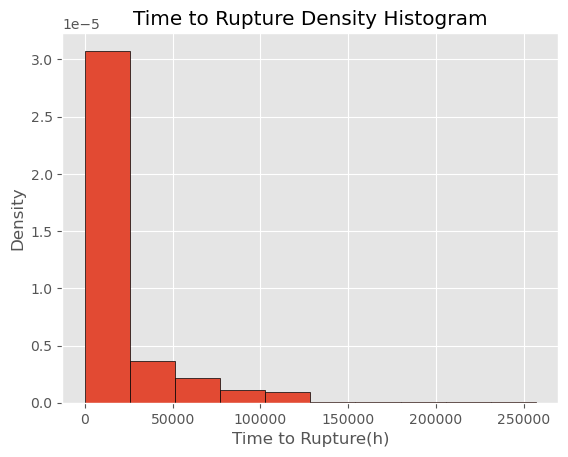

In [13]:
data=pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
y = data['Time to Rupture(h)']

# 绘制直方图
plt.hist(y, edgecolor='black', density=True)

# 添加标题和标签
plt.title('Time to Rupture Density Histogram')
plt.xlabel('Time to Rupture(h)')
plt.ylabel('Density')
# 保存图像为EPS格式
plt.savefig('time_to_rupture_histogram.pdf', format='pdf', dpi=300, bbox_inches='tight', transparent=True)
# 显示图形
plt.show()

In [14]:
filtered_data = data[data['Time to Rupture(h)'] >= 2500]

# 保存过滤后的数据到新的 excel 文件
filtered_data.to_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx', index=False)

In [15]:
filtered_data.describe()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,pierced,rolled,rotary,vacuum,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
count,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,...,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000
mean,0.101732,0.393781,0.908777,0.017941,0.005936,10.346346,13.008916,0.686278,0.370552,0.301458,...,0.076793,0.075876,0.076793,0.026192,641.308793,236.519829,125.240082,21.811643,39.401826,30337.307566
std,0.059307,0.208031,0.556002,0.007963,0.005771,15.902894,6.681515,0.897252,0.726311,0.685385,...,0.192924,0.210690,0.192924,0.106394,93.588658,149.117480,100.658449,13.971561,28.628210,35676.647474
min,0.039000,0.077000,0.056000,0.002000,0.000800,0.000000,0.040000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,450.000000,40.000000,7.000000,0.600000,0.000000,2500.500000
25%,0.070000,0.240000,0.460000,0.012000,0.001000,0.140000,8.530000,0.040000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,600.000000,150.000000,53.000000,12.000000,15.000000,6707.300000
50%,0.090000,0.380000,0.600000,0.018000,0.004000,8.790000,15.370000,0.420000,0.000000,0.050000,...,0.000000,0.000000,0.000000,0.000000,650.000000,172.000000,100.000000,20.000000,34.000000,15557.400000
75%,0.110000,0.550000,1.570000,0.025000,0.009000,12.620000,18.200000,0.940000,0.000000,0.130000,...,0.000000,0.000000,0.000000,0.000000,700.000000,269.000000,176.000000,29.000000,61.000000,41924.200000
max,0.430000,1.200000,1.710000,0.030000,0.026000,75.350000,25.600000,3.740000,2.480000,2.920000,...,0.560477,0.724941,0.560477,0.463951,1000.000000,1029.000000,900.000000,109.000000,96.000000,257021.000000


In [2]:
data = pd.read_excel(r'D:/creep rupture/添加高温测试和高应力\TR大于2500.xlsx')
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
data_scaled.to_excel(r'D:/creep rupture/添加高温测试和高应力/TR大于2500_Scaled.xlsx', index=False)

In [3]:
data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力/TR大于2500_Scaled.xlsx')

# 根据你提供的代码，处理你的表格数据
x = data.drop(columns=[ 'Time to Rupture(h)'])
y = data['Time to Rupture(h)']

In [4]:
# 假设你的数据集中有多少个特性
num_features = x.shape[1]
# 假设你的输出是一个值
output_dim = 1

# 定义一些基本的参数
latent_dim = 100
num_classes = num_features
optimizer = Adam(0.0002, 0.5)

In [5]:
def create_generator():
    # 输入1: 噪声
    noise = Input(shape=(latent_dim,), name='g_noise')
    # 输入2：条件或标签
    condition = Input(shape=(1,), name='g_condition')
    
    i = Embedding(input_dim=num_classes, output_dim=output_dim, input_length=1)(condition)
    i = Flatten()(i)
    
    model_input = multiply([noise, i])

    # 建立生成器网络
    g = Sequential()
    g.add(Dense(256, input_shape=(latent_dim,)))
    g.add(BatchNormalization())  # 添加批归一化层
    g.add(LeakyReLU(alpha=0.2))
    g.add(Dropout(0.3))
    g.add(Dense(512))
    g.add(BatchNormalization())  # 添加批归一化层
    g.add(LeakyReLU(alpha=0.2))
    g.add(Dropout(0.3))
    g.add(Dense(1024))
    g.add(BatchNormalization())  # 添加批归一化层
    g.add(LeakyReLU(alpha=0.2))
    g.add(Dropout(0.3))
    g.add(Dense(num_features, activation='linear'))
    model_input = g(model_input)
    
    return Model([noise, condition], model_input)

In [6]:
# 创建判别器
def create_discriminator():
    # 输入1: 数据特征
    num_set = Input(shape=(num_features,), name='d_input')
    # 输入2：条件或标签
    condition = Input(shape=(1,), name='d_condition')

    i = Embedding(input_dim=num_classes, output_dim=latent_dim, input_length=1)(condition)
    i = Flatten()(i)
    i = Dense(num_features)(i)

    model_input = multiply([num_set, i])

    # 建立判别器网络
    d = Sequential()
    d.add(Dense(512, input_shape=(num_features,)))
    d.add(BatchNormalization())  # 添加批归一化层
    d.add(LeakyReLU(alpha=0.2))
    d.add(Dense(256))
    d.add(BatchNormalization())  # 添加批归一化层
    d.add(LeakyReLU(alpha=0.2))
    d.add(Dense(1, activation='linear'))
    model_input = d(model_input)
    return Model([num_set, condition], model_input)

In [7]:
def root_mean_squared_error(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

generator = create_generator()
discriminator = create_discriminator()

optimizer = 'adam'  # 选择优化器
discriminator.compile(loss=root_mean_squared_error, optimizer=optimizer, metrics=[root_mean_squared_error])

In [8]:
# 用于组合的 CGAN 模型
z = Input(shape=(latent_dim,))
label = Input(shape=(1,))
generated_features = generator([z, label])

# 在组合模型中，判别器不进行训练
discriminator.trainable = False

real_or_fake = discriminator([generated_features, label])
cgan = Model([z, label], real_or_fake)
cgan.compile(loss=root_mean_squared_error, optimizer=optimizer)

In [9]:
# 训练过程
def train(generator, discriminator, cgan, epochs, batch_size=128):
    half_batch = int(batch_size / 2)
    d_loss_real_list = []
    d_loss_fake_list = []
    g_loss_list = []

    for epoch in range(epochs):
        # 训练判别器
        indices = np.random.randint(0, x.shape[0], half_batch)
        features, labels = x.iloc[indices], y.iloc[indices]

        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        gen_features = generator.predict([noise, labels])

        d_loss_real = discriminator.train_on_batch([features, labels], np.ones((half_batch, 1)))
        d_loss_fake = discriminator.train_on_batch([gen_features, labels], np.zeros((half_batch, 1)))

        # 训练生成器
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        sampled_labels = np.random.randint(0, num_classes, batch_size).reshape(-1, 1)
        
        # 保存损失值到列表中
        d_loss_real_list.append(d_loss_real[0])
        d_loss_fake_list.append(d_loss_fake[0])
        g_loss = cgan.train_on_batch([noise, sampled_labels], np.ones((batch_size, 1)))
        g_loss_list.append(g_loss)

        print(f"{epoch+1}/{epochs} [D loss: {d_loss_real[0] + d_loss_fake[0]}] [G loss: {g_loss}]")
        
    return d_loss_real_list,d_loss_fake_list,g_loss_list

# 使用 train 函数进行训练
epochs = 5000
batch_size = 128
d_loss_real_list, d_loss_fake_list, g_loss_list = train(generator, discriminator, cgan, epochs, batch_size)

2/2 [==============================] - 0s 10ms/step
1/5000 [D loss: 0.9101291298866272] [G loss: 0.9811276793479919]
2/2 [==============================] - 0s 8ms/step
2/5000 [D loss: 2.0302299484610558] [G loss: 0.9791857004165649]
2/2 [==============================] - 0s 5ms/step
3/5000 [D loss: 1.5894415602087975] [G loss: 0.9844058752059937]
2/2 [==============================] - 0s 10ms/step
4/5000 [D loss: 0.9420332610607147] [G loss: 0.9851862192153931]
2/2 [==============================] - 0s 19ms/step
5/5000 [D loss: 1.2494229152798653] [G loss: 0.9935613870620728]
2/2 [==============================] - 0s 7ms/step
6/5000 [D loss: 1.4263539463281631] [G loss: 1.0047396421432495]
2/2 [==============================] - 0s 12ms/step
7/5000 [D loss: 0.7163018882274628] [G loss: 1.011867880821228]
2/2 [==============================] - 0s 6ms/step
8/5000 [D loss: 0.6454840898513794] [G loss: 1.0117228031158447]
2/2 [==============================] - 0s 4ms/step
9/5000 [D loss: 0.

2/2 [==============================] - 0s 7ms/step
71/5000 [D loss: 0.3427092432975769] [G loss: 0.5867114067077637]
2/2 [==============================] - 0s 6ms/step
72/5000 [D loss: 0.3428752198815346] [G loss: 0.5215429067611694]
2/2 [==============================] - 0s 5ms/step
73/5000 [D loss: 0.36062100529670715] [G loss: 0.508720874786377]
2/2 [==============================] - 0s 13ms/step
74/5000 [D loss: 0.28990115225315094] [G loss: 0.5036333203315735]
2/2 [==============================] - 0s 12ms/step
75/5000 [D loss: 0.3278387486934662] [G loss: 0.5329642295837402]
2/2 [==============================] - 0s 16ms/step
76/5000 [D loss: 0.31872836500406265] [G loss: 0.5510584115982056]
2/2 [==============================] - 0s 8ms/step
77/5000 [D loss: 0.4879160225391388] [G loss: 0.5193306803703308]
2/2 [==============================] - 0s 9ms/step
78/5000 [D loss: 0.44418761134147644] [G loss: 0.5066462755203247]
2/2 [==============================] - 0s 4ms/step
79/5000

2/2 [==============================] - 0s 3ms/step
209/5000 [D loss: 0.13866820558905602] [G loss: 0.631755530834198]
2/2 [==============================] - 0s 10ms/step
210/5000 [D loss: 0.21822134405374527] [G loss: 0.5370883941650391]
2/2 [==============================] - 0s 7ms/step
211/5000 [D loss: 0.18235505372285843] [G loss: 0.3774433135986328]
2/2 [==============================] - 0s 12ms/step
212/5000 [D loss: 0.2071656808257103] [G loss: 0.36039939522743225]
2/2 [==============================] - 0s 0s/step
213/5000 [D loss: 0.38671039044857025] [G loss: 0.6240803599357605]
2/2 [==============================] - 0s 6ms/step
214/5000 [D loss: 0.2684183493256569] [G loss: 0.746606707572937]
2/2 [==============================] - 0s 0s/step
215/5000 [D loss: 0.2719903588294983] [G loss: 0.6793968081474304]
2/2 [==============================] - 0s 9ms/step
216/5000 [D loss: 0.21514739841222763] [G loss: 0.5795733332633972]
2/2 [==============================] - 0s 9ms/step
2

2/2 [==============================] - 0s 7ms/step
278/5000 [D loss: 0.28100433200597763] [G loss: 0.4551350772380829]
2/2 [==============================] - 0s 4ms/step
279/5000 [D loss: 0.3171394467353821] [G loss: 0.459214985370636]
2/2 [==============================] - 0s 15ms/step
280/5000 [D loss: 0.27362771332263947] [G loss: 0.5164121389389038]
2/2 [==============================] - 0s 10ms/step
281/5000 [D loss: 0.16770590096712112] [G loss: 0.5164335370063782]
2/2 [==============================] - 0s 6ms/step
282/5000 [D loss: 0.13202010467648506] [G loss: 0.40309464931488037]
2/2 [==============================] - 0s 6ms/step
283/5000 [D loss: 0.15661252662539482] [G loss: 0.465939998626709]
2/2 [==============================] - 0s 10ms/step
284/5000 [D loss: 0.208015576004982] [G loss: 0.45314592123031616]
2/2 [==============================] - 0s 13ms/step
285/5000 [D loss: 0.17966829240322113] [G loss: 0.39588212966918945]
2/2 [==============================] - 0s 7ms/

2/2 [==============================] - 0s 3ms/step
347/5000 [D loss: 0.2005200944840908] [G loss: 0.42604103684425354]
2/2 [==============================] - 0s 6ms/step
348/5000 [D loss: 0.37340502440929413] [G loss: 0.4074212312698364]
2/2 [==============================] - 0s 5ms/step
349/5000 [D loss: 0.2794731557369232] [G loss: 0.5433040261268616]
2/2 [==============================] - 0s 4ms/step
350/5000 [D loss: 0.19831258803606033] [G loss: 0.6645771265029907]
2/2 [==============================] - 0s 4ms/step
351/5000 [D loss: 0.1627049259841442] [G loss: 0.6212278008460999]
2/2 [==============================] - 0s 4ms/step
352/5000 [D loss: 0.1967504769563675] [G loss: 0.4386039674282074]
2/2 [==============================] - 0s 4ms/step
353/5000 [D loss: 0.22549725323915482] [G loss: 0.30417609214782715]
2/2 [==============================] - 0s 9ms/step
354/5000 [D loss: 0.2754427120089531] [G loss: 0.3807961642742157]
2/2 [==============================] - 0s 4ms/step


...

2/2 [==============================] - 0s 10ms/step
4580/5000 [D loss: 0.13380130380392075] [G loss: 0.5604325532913208]
2/2 [==============================] - 0s 0s/step
4581/5000 [D loss: 0.08713449537754059] [G loss: 0.5459590554237366]
2/2 [==============================] - 0s 10ms/step
4582/5000 [D loss: 0.07919022813439369] [G loss: 0.5653867125511169]
2/2 [==============================] - 0s 7ms/step
4583/5000 [D loss: 0.08562901243567467] [G loss: 0.5572320222854614]
2/2 [==============================] - 0s 11ms/step
4584/5000 [D loss: 0.05833633616566658] [G loss: 0.5715649127960205]
2/2 [==============================] - 0s 5ms/step
4585/5000 [D loss: 0.08751245588064194] [G loss: 0.554848849773407]
2/2 [==============================] - 0s 0s/step
4586/5000 [D loss: 0.11435026675462723] [G loss: 0.5565479397773743]
2/2 [==============================] - 0s 10ms/step
4587/5000 [D loss: 0.09524963423609734] [G loss: 0.5507237315177917]
2/2 [==============================] - 

4715/5000 [D loss: 0.12539996206760406] [G loss: 0.4096609354019165]
2/2 [==============================] - 0s 8ms/step
4716/5000 [D loss: 0.09224489517509937] [G loss: 0.4154726564884186]
2/2 [==============================] - 0s 18ms/step
4717/5000 [D loss: 0.09961339831352234] [G loss: 0.4382236897945404]
2/2 [==============================] - 0s 0s/step
4718/5000 [D loss: 0.0995748657733202] [G loss: 0.47543197870254517]
2/2 [==============================] - 0s 6ms/step
4719/5000 [D loss: 0.153105728328228] [G loss: 0.4383437931537628]
2/2 [==============================] - 0s 6ms/step
4720/5000 [D loss: 0.06368556804955006] [G loss: 0.4383150637149811]
2/2 [==============================] - 0s 6ms/step
4721/5000 [D loss: 0.04944288078695536] [G loss: 0.40713468194007874]
2/2 [==============================] - 0s 6ms/step
4722/5000 [D loss: 0.12641938775777817] [G loss: 0.42837387323379517]
2/2 [==============================] - 0s 6ms/step
4723/5000 [D loss: 0.04737962316721678] 

2/2 [==============================] - 0s 7ms/step
4784/5000 [D loss: 0.06255127489566803] [G loss: 0.450216144323349]
2/2 [==============================] - 0s 10ms/step
4785/5000 [D loss: 0.06030873581767082] [G loss: 0.45318999886512756]
2/2 [==============================] - 0s 4ms/step
4786/5000 [D loss: 0.1224479228258133] [G loss: 0.4383389949798584]
2/2 [==============================] - 0s 3ms/step
4787/5000 [D loss: 0.05228647403419018] [G loss: 0.44318628311157227]
2/2 [==============================] - 0s 4ms/step
4788/5000 [D loss: 0.07789029739797115] [G loss: 0.4326707720756531]
2/2 [==============================] - 0s 15ms/step
4789/5000 [D loss: 0.11593028530478477] [G loss: 0.41327598690986633]
2/2 [==============================] - 0s 11ms/step
4790/5000 [D loss: 0.09164893627166748] [G loss: 0.3942151963710785]
2/2 [==============================] - 0s 6ms/step
4791/5000 [D loss: 0.13890701159834862] [G loss: 0.4329833388328552]
2/2 [==============================]

2/2 [==============================] - 0s 5ms/step
4852/5000 [D loss: 0.07403415814042091] [G loss: 0.4150856137275696]
2/2 [==============================] - 0s 6ms/step
4853/5000 [D loss: 0.05545168090611696] [G loss: 0.41839534044265747]
2/2 [==============================] - 0s 6ms/step
4854/5000 [D loss: 0.07024280447512865] [G loss: 0.40893763303756714]
2/2 [==============================] - 0s 18ms/step
4855/5000 [D loss: 0.14258280023932457] [G loss: 0.4070928394794464]
2/2 [==============================] - 0s 8ms/step
4856/5000 [D loss: 0.07750445045530796] [G loss: 0.3963509798049927]
2/2 [==============================] - 0s 9ms/step
4857/5000 [D loss: 0.11420627683401108] [G loss: 0.40816372632980347]
2/2 [==============================] - 0s 11ms/step
4858/5000 [D loss: 0.10056589730083942] [G loss: 0.39731699228286743]
2/2 [==============================] - 0s 8ms/step
4859/5000 [D loss: 0.14176082611083984] [G loss: 0.39444246888160706]
2/2 [============================

4987/5000 [D loss: 0.0697461050003767] [G loss: 0.4591135084629059]
2/2 [==============================] - 0s 6ms/step
4988/5000 [D loss: 0.0893093217164278] [G loss: 0.4808429181575775]
2/2 [==============================] - 0s 6ms/step
4989/5000 [D loss: 0.12470117211341858] [G loss: 0.45961523056030273]
2/2 [==============================] - 0s 4ms/step
4990/5000 [D loss: 0.08315381407737732] [G loss: 0.4581625461578369]
2/2 [==============================] - 0s 12ms/step
4991/5000 [D loss: 0.1373467743396759] [G loss: 0.4561525583267212]
2/2 [==============================] - 0s 16ms/step
4992/5000 [D loss: 0.06745841726660728] [G loss: 0.4647422134876251]
2/2 [==============================] - 0s 4ms/step
4993/5000 [D loss: 0.14419318363070488] [G loss: 0.43245938420295715]
2/2 [==============================] - 0s 15ms/step
4994/5000 [D loss: 0.15277932211756706] [G loss: 0.4140672981739044]
2/2 [==============================] - 0s 5ms/step
4995/5000 [D loss: 0.1340302899479866]

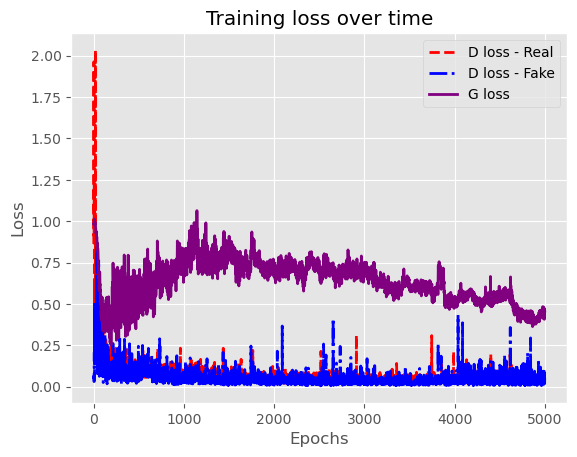

In [10]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')  # 设置样式为 ggplot
plt.plot(range(epochs), d_loss_real_list, color='red', linewidth=2, linestyle='--', label='D loss - Real')
plt.plot(range(epochs), d_loss_fake_list, color='blue', linewidth=2, linestyle='-.', label='D loss - Fake')
plt.plot(range(epochs), g_loss_list, color='purple', linewidth=2, linestyle='-', label='G loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training loss over time')
plt.legend(loc='best')
plt.grid(True)  # 添加网格线

plt.savefig('CGAN5000loss_plot.pdf', format='pdf', bbox_inches='tight', dpi=300)  # 保存为 PDF 格式
plt.show()

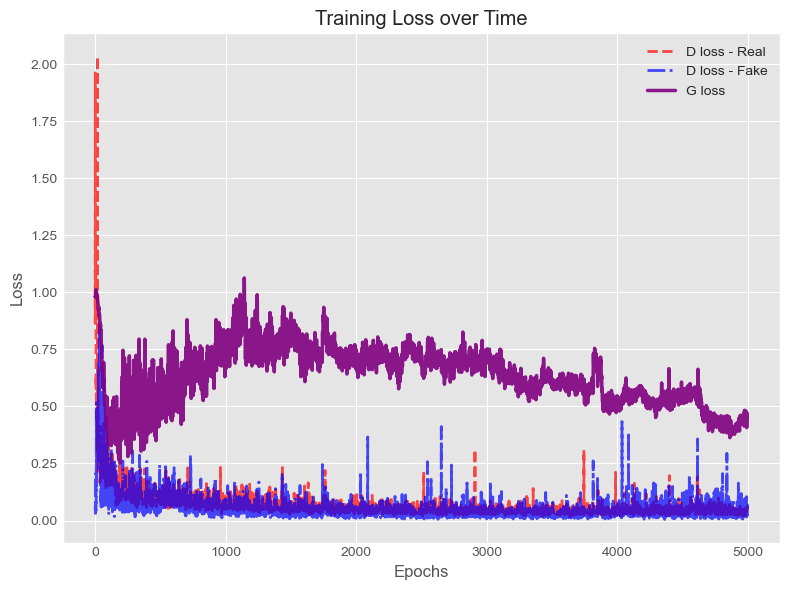

In [30]:
import matplotlib.pyplot as plt

# 设置样式为 ggplot
plt.style.use('ggplot')

# 创建一个新的 Figure 对象
fig, ax = plt.subplots(figsize=(8, 6))

# 画出每个损失函数的变化曲线
ax.plot(range(epochs), d_loss_real_list, linewidth=2, linestyle='--', label='D loss - Real', color='red', alpha=0.7)
ax.plot(range(epochs), d_loss_fake_list, linewidth=2, linestyle='-.', label='D loss - Fake', color='blue', alpha=0.7)
ax.plot(range(epochs), g_loss_list, linewidth=2.5, linestyle='-', label='G loss', color='purple', alpha=0.9)

# 添加标题和标签
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Training Loss over Time')

# 添加网格线
ax.grid(True)

# 调整坐标轴刻度的字体大小
ax.tick_params(axis='both', which='major', labelsize=10)

# 添加图例，放在图表的右上角
ax.legend(loc='upper right')

# 调整整个图表（包括周围的空白）的边距
plt.tight_layout()

# 保存为 PDF 格式，并设置分辨率
plt.savefig('loss_plot.pdf', dpi=300)

# 显示图像
plt.show()

In [11]:
# 生成虚拟数据
num_samples = 489
noise = np.random.normal(0, 1, (num_samples, latent_dim))
sampled_labels = np.random.randint(0, num_classes, num_samples).reshape(-1, 1)
generated_features = generator.predict([noise, sampled_labels])

# 将生成的数据保存为 pandas DataFrame
generated_data = pd.DataFrame(generated_features, columns=x.columns)
generated_data['Time to Rupture(h)'] = y.max()  # 此处将生成的数据的时间设置为真实数据的最大时间

# 输出生成的数据
generated_data.head()

16/16 [==============================] - 0s 5ms/step


,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,pierced,rolled,rotary,vacuum,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,1457.520508,304.223633,-5151.866211,-1262.990234,-442.525757,481.831696,2132.860107,-2549.291504,167.780258,-775.449585,...,-4040.822754,3445.900146,175.392990,2433.404297,121.654892,1354.928711,-1264.417480,-532.812866,441.569794,6.360346
1,923.988831,928.998718,-4429.702637,-365.467651,348.524536,268.665375,3983.781250,-2534.519775,-1647.225464,-1297.403564,...,-3729.444336,4021.086914,1088.319458,3359.416260,-270.958405,1675.883911,-2092.969482,-492.942139,980.580322,6.360346
2,96.630630,77.560928,-352.408203,134.691193,-51.854385,350.372620,385.888519,-60.103748,-389.868591,-356.479309,...,-284.961090,410.933228,259.830383,579.603271,-180.445770,361.018707,-196.467651,-274.936340,61.142853,6.360346
3,1702.924927,124.568375,-5639.514648,-1590.982788,-718.984009,615.229187,1668.407471,-2664.843750,713.563721,-686.144714,...,-4341.763184,3453.036865,-77.998436,2309.999756,226.474915,1358.497681,-1072.026245,-602.888672,292.031158,6.360346
4,786.557434,1083.369995,-4221.196289,-119.793465,539.848877,243.450699,4437.215820,-2499.945801,-2123.428467,-1444.007202,...,-3622.527100,4148.255371,1332.213745,3603.220947,-389.735687,1776.150513,-2293.632080,-499.957886,1109.316406,6.360346


In [16]:
# 假设 filtered_data 是您原始数据的 pandas DataFrame
std = filtered_data.describe().loc['std']
mean = filtered_data.describe().loc['mean']
# 将生成的数据逆标准化
generated_data_inverse = generated_data * std + mean
distances = np.linalg.norm(filtered_data.values - generated_data_inverse.values, axis=1)
indices_sorted = np.argsort(distances)
k = 200  # 选择距离最近的前 k 个数据点
nearest_indices = indices_sorted[:k]
nearest_data = filtered_data.iloc[nearest_indices]

In [2]:
# 将逆标准化后的生成数据保
nearest_data.to_excel(r'D:\creep rupture\添加高温测试和高应力\generated_data_inverse2.xlsx', index=False)

NameError: name 'nearest_data' is not defined

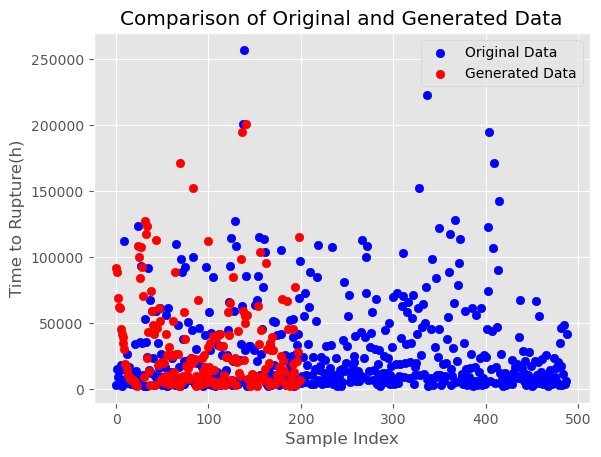

In [19]:
import matplotlib.pyplot as plt

# 选择一个特定的特征进行可视化
feature_name = 'Time to Rupture(h)'

# 原始数据
plt.scatter(range(len(filtered_data)), filtered_data[feature_name], label='Original Data', c='b')
# 生成的数据
plt.scatter(range(len(nearest_data)), nearest_data[feature_name], label='Generated Data', c='r')

plt.xlabel('Sample Index')
plt.ylabel(feature_name)
plt.title('Comparison of Original and Generated Data')
plt.legend(loc='upper right')
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_69524\1336898753.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='Original Data')
C:\Users\zangd\AppData\Local\Temp\ipykernel_69524\1336898753.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='Generated Data')


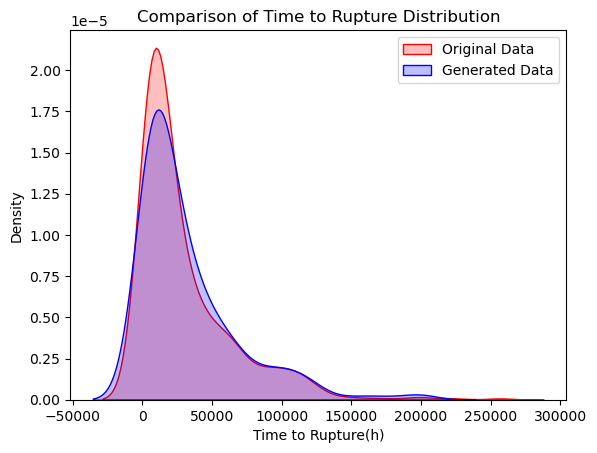

In [3]:
import seaborn as sns

sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='Original Data')
sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='Generated Data')
plt.xlabel('Time to Rupture(h)')
plt.ylabel('Density')
plt.title('Comparison of Time to Rupture Distribution')
plt.legend() 
plt.show()

In [5]:
import pandas as pd
import numpy as np

In [6]:
nearest_data=pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\generated_data_inverse2.xlsx')
filtered_data=pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

C:\Users\zangd\AppData\Local\Temp\ipykernel_69524\2666283439.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='Real Data', linewidth=2)
C:\Users\zangd\AppData\Local\Temp\ipykernel_69524\2666283439.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='Generated Data', linewidth=2, alpha=0.7)
C:\Users\zangd\AppData\Local\Temp\ipykernel_69524\2666283439.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels([f'{tick:.2f}' for tick in plt.gca().get_yticks()], fontname='Arial', fontsize=12, fontweight='bold')


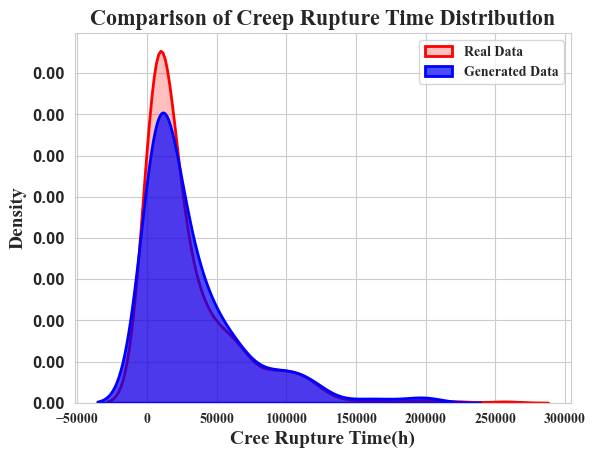

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置图形风格
sns.set_style("whitegrid")

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# 绘制核密度图并调整线条宽度、颜色和透明度
sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='Real Data', linewidth=2)
sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='Generated Data', linewidth=2, alpha=0.7)

# 添加标题和标签
plt.xlabel('Cree Rupture Time(h)', fontsize=14, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Density', fontsize=14, fontname='Times New Roman', fontweight='bold')
plt.title('Comparison of Creep Rupture Time Distribution', fontsize=16, fontname='Times New Roman', fontweight='bold')

# 调整图例位置和样式
plt.legend(loc='upper right', fancybox=True)

# 设置 y 轴刻度字体
plt.gca().set_yticklabels([f'{tick:.2f}' for tick in plt.gca().get_yticks()], fontname='Arial', fontsize=12, fontweight='bold')

# 保存为PDF格式
plt.savefig('核密度分布comparison_plot.pdf', format='pdf')
plt.savefig('核密度分布comparison_plot.png', format='png')

# 显示图形
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_57476\2294357034.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='Real Data', linewidth=2)
C:\Users\zangd\AppData\Local\Temp\ipykernel_57476\2294357034.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='Generated Data', linewidth=2, alpha=0.7)


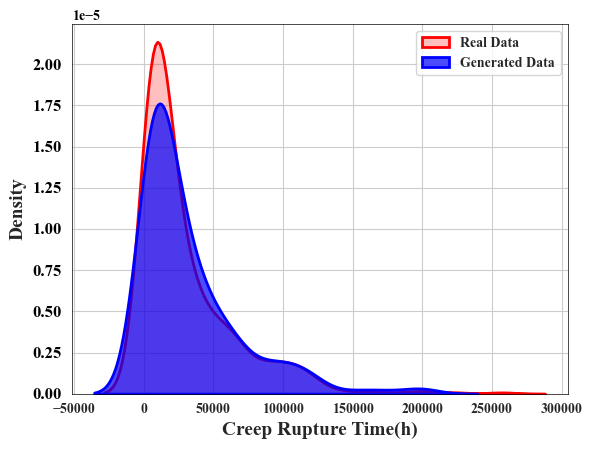

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 设置图形风格
sns.set_style("whitegrid")

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'


# 绘制核密度图并调整线条宽度、颜色和透明度
sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='Real Data', linewidth=2)
sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='Generated Data', linewidth=2, alpha=0.7)

# 添加标题和标签
plt.xlabel('Creep Rupture Time(h)', fontsize=14, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Density', fontsize=14, fontname='Times New Roman', fontweight='bold')

# 调整图例位置和样式
plt.legend(loc='upper right', fancybox=True)

# 设置图标边框为黑色
ax = plt.gca()
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)

# 不要直接设置 y 轴刻度字体，以避免0.00问题
plt.tick_params(axis='y', labelsize=12, labelcolor='black', width=2)

# 保存为PDF格式
plt.savefig('核密度分布comparison_plot.pdf', format='pdf')
plt.savefig('核密度分布comparison_plot.png', format='png')

# 显示图形
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_196376\1064177767.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='真实数据', linewidth=2)
C:\Users\zangd\AppData\Local\Temp\ipykernel_196376\1064177767.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='生成数据', linewidth=2, alpha=0.7)


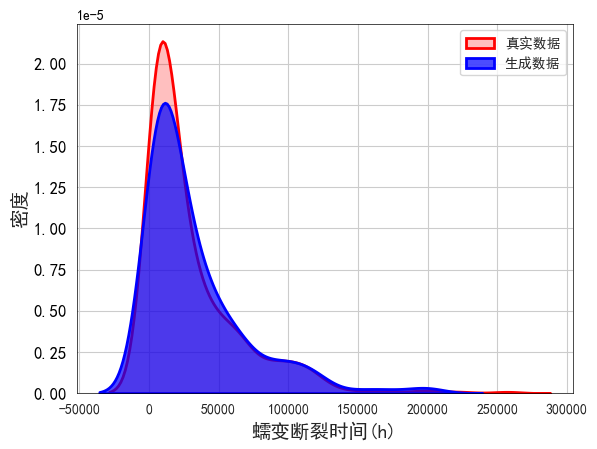

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 设置图形风格
sns.set_style("whitegrid")

# 设置字体为支持中文的字体（例如SimHei）
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 绘制核密度图并调整线条宽度、颜色和透明度
sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='真实数据', linewidth=2)
sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='生成数据', linewidth=2, alpha=0.7)

# 添加标题和标签（中文）
plt.xlabel('蠕变断裂时间(h)', fontsize=14, fontname='SimHei')
plt.ylabel('密度', fontsize=14, fontname='SimHei')

# 调整图例位置和样式（中文）
plt.legend(loc='upper right', fancybox=True)

# 设置图标边框为黑色
ax = plt.gca()
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)

# 不要直接设置 y 轴刻度字体，以避免0.00问题
plt.tick_params(axis='y', labelsize=12, labelcolor='black', width=2)

# 保存为PDF格式
plt.savefig('核密度分布蠕变.pdf', format='pdf')
plt.savefig('核密度分布蠕变.png', format='png')

# 显示图形
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_33384\1451629925.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='Real Data', linewidth=2)
C:\Users\zangd\AppData\Local\Temp\ipykernel_33384\1451629925.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='Generated Data', linewidth=2, alpha=0.7)


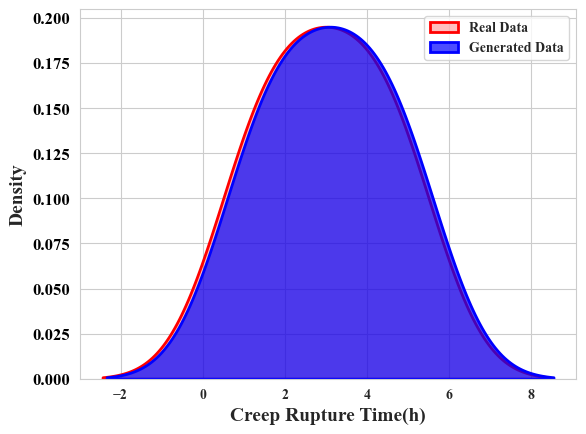

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置图形风格
sns.set_style("whitegrid")

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# 示例数据框架
# import pandas as pd
# filtered_data = pd.DataFrame({'Time to Rupture(h)': [1, 2, 3, 4, 5]})
# nearest_data = pd.DataFrame({'Time to Rupture(h)': [1.1, 2.1, 3.1, 4.1, 5.1]})

# 绘制核密度图并调整线条宽度、颜色和透明度
sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='Real Data', linewidth=2)
sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='Generated Data', linewidth=2, alpha=0.7)

# 添加标题和标签
plt.xlabel('Creep Rupture Time(h)', fontsize=14, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Density', fontsize=14, fontname='Times New Roman', fontweight='bold')

# 调整图例位置和样式
plt.legend(loc='upper right', fancybox=True)

# 不要直接设置 y 轴刻度字体，以避免0.00问题
plt.tick_params(axis='y', labelsize=12, labelcolor='black', width=2)

# 保存为PDF格式
plt.savefig('核密度分布comparison_plot.pdf', format='pdf')
plt.savefig('核密度分布comparison_plot.png', format='png')

# 显示图形
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_52276\1182817431.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color=colors[0], label='Original Data', linewidth=2)
C:\Users\zangd\AppData\Local\Temp\ipykernel_52276\1182817431.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color=colors[1], label='Generated Data', linewidth=2, alpha=0.7)
C:\Users\zangd\AppData\Local\Temp\ipykernel_52276\1182817431.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels([f'{tick:.2f}' for tick in plt.gca().get_yticks()], fontname='Arial', fontsize=12, fontweight='bold')
C:\Users\zangd\AppData\Local\Temp\ip

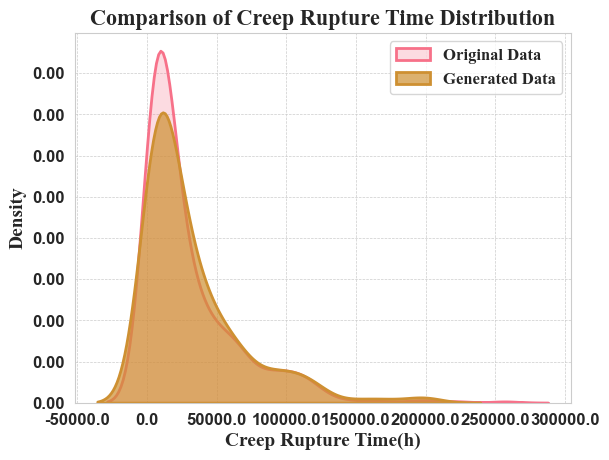

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置图形风格
sns.set_style("whitegrid")

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# 设置颜色调色板
colors = sns.color_palette("husl", 8)

# 绘制核密度图并调整线条宽度、颜色和透明度
sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color=colors[0], label='Original Data', linewidth=2)
sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color=colors[1], label='Generated Data', linewidth=2, alpha=0.7)

# 添加标题和标签
plt.xlabel('Creep Rupture Time(h)', fontsize=14, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Density', fontsize=14, fontname='Times New Roman', fontweight='bold')
plt.title('Comparison of Creep Rupture Time Distribution', fontsize=16, fontname='Times New Roman', fontweight='bold')

# 调整图例位置和样式
plt.legend(loc='upper right', fancybox=True, frameon=True, fontsize=12)

# 设置 y 轴刻度字体
plt.gca().set_yticklabels([f'{tick:.2f}' for tick in plt.gca().get_yticks()], fontname='Arial', fontsize=12, fontweight='bold')
plt.gca().set_xticklabels([f'{tick:.1f}' for tick in plt.gca().get_xticks()], fontname='Arial', fontsize=12, fontweight='bold')

# 增加网格线
plt.grid(True, linestyle='--', linewidth=0.5)

# 保存为PDF格式
plt.savefig('核密度分布comparison_plot1.pdf', format='pdf', bbox_inches='tight')

# 显示图形
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_30332\1501611825.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='Original Data', linewidth=2)
C:\Users\zangd\AppData\Local\Temp\ipykernel_30332\1501611825.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='Generated Data', linewidth=2, alpha=0.7)


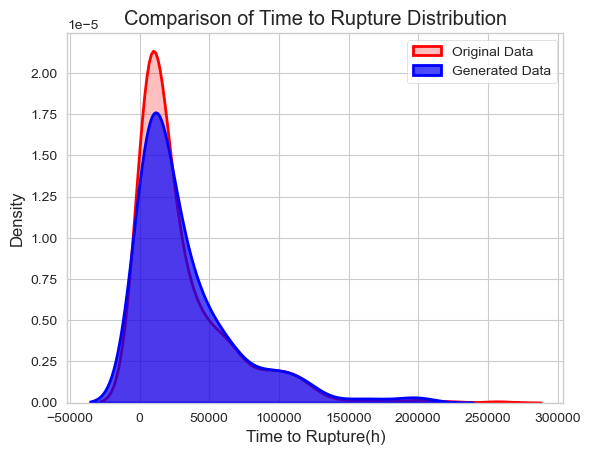

In [24]:
import seaborn as sns

# 设置图形风格
sns.set_style("whitegrid")

# 绘制核密度图并调整线条宽度、颜色和透明度
sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='Original Data', linewidth=2)
sns.kdeplot(nearest_data['Time to Rupture(h)'], shade=True, color='blue', label='Generated Data', linewidth=2, alpha=0.7)

# 添加标题和标签
plt.xlabel('Time to Rupture(h)')
plt.ylabel('Density')
plt.title('Comparison of Time to Rupture Distribution')

# 调整图例位置和样式
plt.legend(loc='upper right', fancybox=True)

# 保存为PDF格式
plt.savefig('核密度分布comparison_plot.pdf', format='pdf')

# 显示图形
plt.show()

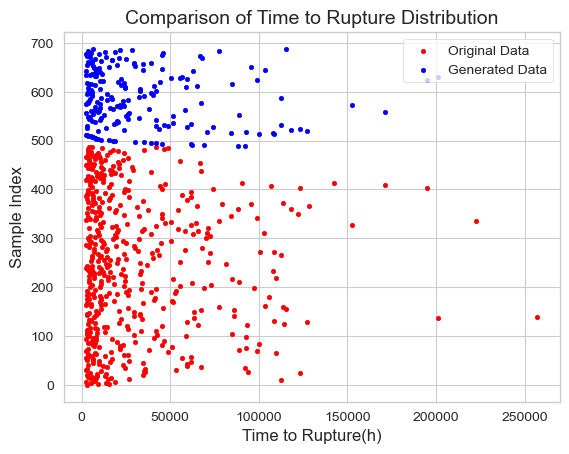

In [27]:
import matplotlib.pyplot as plt

# 绘制散点图
plt.scatter(filtered_data['Time to Rupture(h)'], range(0, len(filtered_data)), s=10, c='red', label='Original Data')
plt.scatter(nearest_data['Time to Rupture(h)'], range(len(filtered_data), len(nearest_data) + len(filtered_data)), s=10, c='blue', label='Generated Data')

# 添加标题和标签，并调整字体大小
plt.xlabel('Time to Rupture(h)', fontsize=12)
plt.ylabel('Sample Index', fontsize=12)
plt.title('Comparison of Time to Rupture Distribution', fontsize=14)

# 调整图例位置和样式
plt.legend(loc='upper right', fontsize=10)

# 保存为PDF格式
plt.savefig('散点comparison_plot.pdf', format='pdf')

# 显示图形
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_196376\2483612298.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='真实数据', linewidth=2, ax=axs[0])


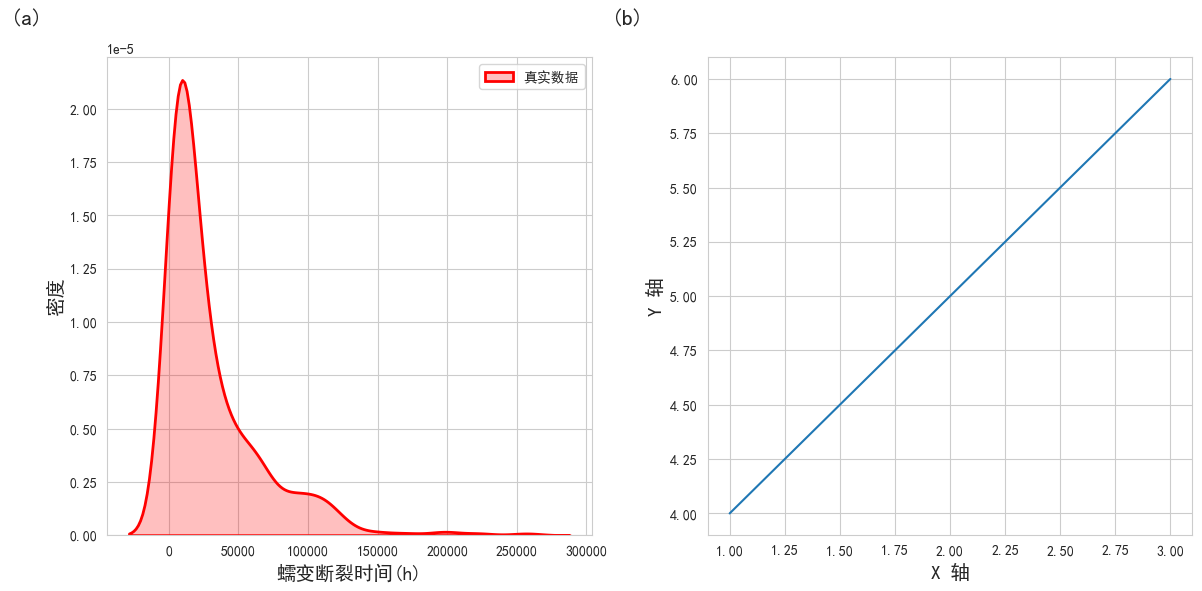

In [8]:
import matplotlib.pyplot as plt

# 创建图形和子图
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# 绘制第一幅图
sns.kdeplot(filtered_data['Time to Rupture(h)'], shade=True, color='red', label='真实数据', linewidth=2, ax=axs[0])
axs[0].set_xlabel('蠕变断裂时间(h)', fontsize=14, fontname='SimHei')
axs[0].set_ylabel('密度', fontsize=14, fontname='SimHei')
axs[0].legend(loc='upper right', fancybox=True)
axs[0].text(-0.2, 1.1, '(a)', transform=axs[0].transAxes, fontsize=16, fontweight='bold', va='top')

# 绘制第二幅图
axs[1].plot([1, 2, 3], [4, 5, 6])  # 这里替换为你实际的绘图代码
axs[1].set_xlabel('X 轴', fontsize=14, fontname='SimHei')
axs[1].set_ylabel('Y 轴', fontsize=14, fontname='SimHei')
axs[1].text(-0.2, 1.1, '(b)', transform=axs[1].transAxes, fontsize=16, fontweight='bold', va='top')

# 调整布局
plt.tight_layout()

# 保存图像
plt.savefig('核密度分布comparison_plot_中文.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('蠕变PCA.png', format='png', dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

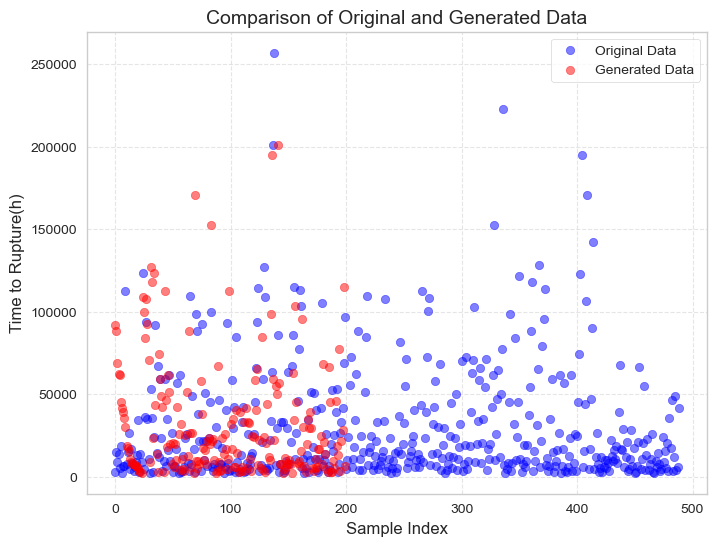

In [28]:
import matplotlib.pyplot as plt

# 选择一个特定的特征进行可视化
feature_name = 'Time to Rupture(h)'

# 创建一个新的Figure对象
fig, ax = plt.subplots(figsize=(8, 6))

# 原始数据
ax.scatter(range(len(filtered_data)), filtered_data[feature_name], label='Original Data', color='blue', alpha=0.5)
# 生成的数据
ax.scatter(range(len(nearest_data)), nearest_data[feature_name], label='Generated Data', color='red', alpha=0.5)

# 添加标题和标签，并调整字体大小
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel(feature_name, fontsize=12)
ax.set_title('Comparison of Original and Generated Data', fontsize=14)

# 添加网格线
ax.grid(True, linestyle='--', alpha=0.5)

# 设置坐标轴刻度
ax.tick_params(labelsize=10)

# 调整图例位置和样式
ax.legend(loc='upper right', fontsize=10)

# 保存为PDF格式
plt.savefig('散点2comparison_plot.pdf', format='pdf')

# 显示图形
plt.show()

## PCA降维散点图

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib import rcParams

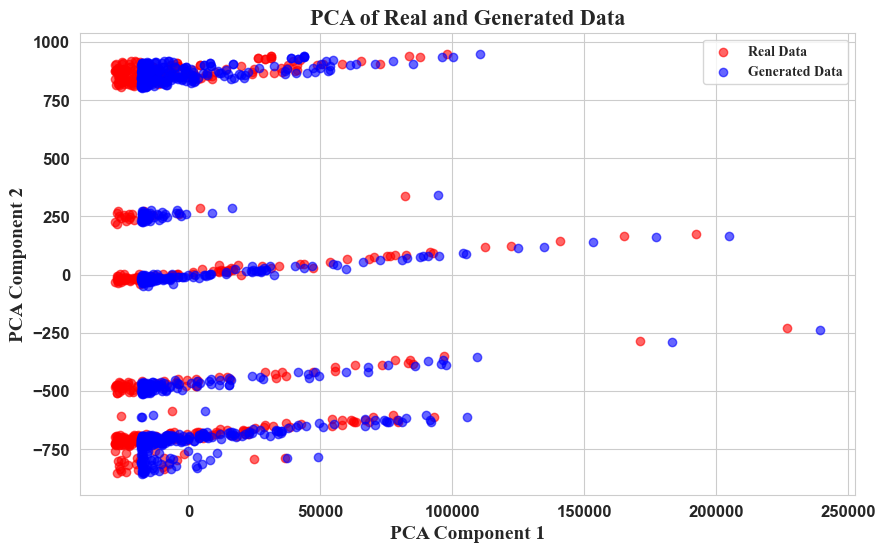

In [11]:
# 配置 Matplotlib 以使用 Times New Roman 和 Arial 字体
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Times New Roman'
rcParams['mathtext.it'] = 'Times New Roman:italic'
rcParams['mathtext.bf'] = 'Times New Roman:bold'

# 读取数据
generated_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
real_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

# 确保数据中没有缺失值，并将数据标准化（这一步可能需要根据具体数据情况调整）
generated_data = generated_data.dropna()
real_data = real_data.dropna()

# 选择需要进行PCA的特征列（假设所有列都是特征）
features_generated = generated_data.iloc[:, :]
features_real = real_data.iloc[:, :]

# PCA降维到2维
pca = PCA(n_components=2)
pca_result_generated = pca.fit_transform(features_generated)
pca_result_real = pca.fit_transform(features_real)

# 将PCA结果转换为DataFrame
pca_df_generated = pd.DataFrame(pca_result_generated, columns=['PCA1', 'PCA2'])
pca_df_real = pd.DataFrame(pca_result_real, columns=['PCA1', 'PCA2'])

# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(pca_df_real['PCA1'], pca_df_real['PCA2'], color='red', label='Real Data', alpha=0.6)
plt.scatter(pca_df_generated['PCA1'], pca_df_generated['PCA2'], color='blue', label='Generated Data', alpha=0.6)

# 添加标题和标签
plt.xlabel('PCA Component 1', fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel('PCA Component 2', fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.title('PCA of Real and Generated Data', fontsize=16, fontweight='bold', fontname='Times New Roman')

# 调整图例位置和样式
plt.legend(loc='upper right', fancybox=True, prop={'family': 'Times New Roman'})

# 美化坐标轴
plt.xticks(fontsize=12, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=12, fontname='Arial', fontweight='bold')

# 保存图片
plt.savefig('PCAcomparison_plot.pdf', format='pdf')
plt.savefig('PCAcomparison_plot.png', format='png')

# 显示图形
plt.show()

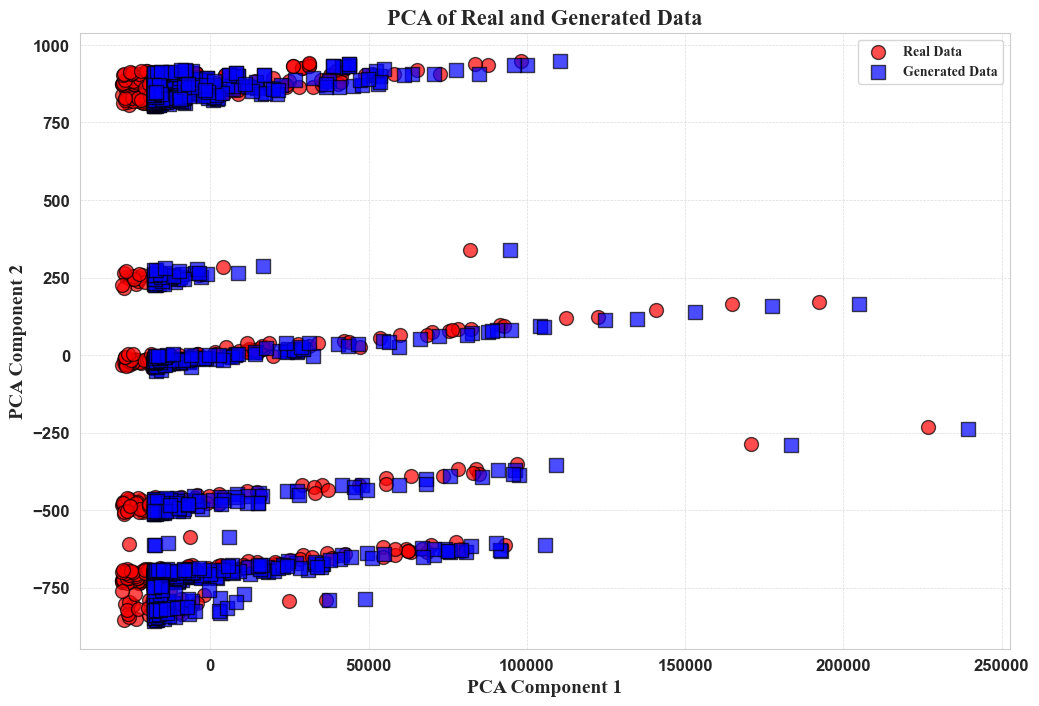

In [12]:
# 配置 Matplotlib 以使用 Times New Roman 和 Arial 字体
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Times New Roman'
rcParams['mathtext.it'] = 'Times New Roman:italic'
rcParams['mathtext.bf'] = 'Times New Roman:bold'

# 读取数据
generated_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
real_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

# 确保数据中没有缺失值，并将数据标准化（这一步可能需要根据具体数据情况调整）
generated_data = generated_data.dropna()
real_data = real_data.dropna()

# 选择需要进行PCA的特征列（假设所有列都是特征）
features_generated = generated_data.iloc[:, :]
features_real = real_data.iloc[:, :]

# PCA降维到2维
pca = PCA(n_components=2)
pca_result_generated = pca.fit_transform(features_generated)
pca_result_real = pca.fit_transform(features_real)

# 将PCA结果转换为DataFrame
pca_df_generated = pd.DataFrame(pca_result_generated, columns=['PCA1', 'PCA2'])
pca_df_real = pd.DataFrame(pca_result_real, columns=['PCA1', 'PCA2'])

# 绘制散点图
plt.figure(figsize=(12, 8))

plt.scatter(pca_df_real['PCA1'], pca_df_real['PCA2'], color='red', edgecolor='k', label='Real Data', alpha=0.7, s=100, marker='o')
plt.scatter(pca_df_generated['PCA1'], pca_df_generated['PCA2'], color='blue', edgecolor='k', label='Generated Data', alpha=0.7, s=100, marker='s')

# 添加标题和标签
plt.xlabel('PCA Component 1', fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel('PCA Component 2', fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.title('PCA of Real and Generated Data', fontsize=16, fontweight='bold', fontname='Times New Roman')

# 调整图例位置和样式
plt.legend(loc='upper right', fancybox=True, prop={'family': 'Times New Roman'})

# 美化坐标轴
plt.xticks(fontsize=12, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=12, fontname='Arial', fontweight='bold')

# 添加网格线
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# 保存图片
plt.savefig('PCAcomparison_plot.pdf', format='pdf')
plt.savefig('PCAcomparison_plot.png', format='png')

# 显示图形
plt.show()

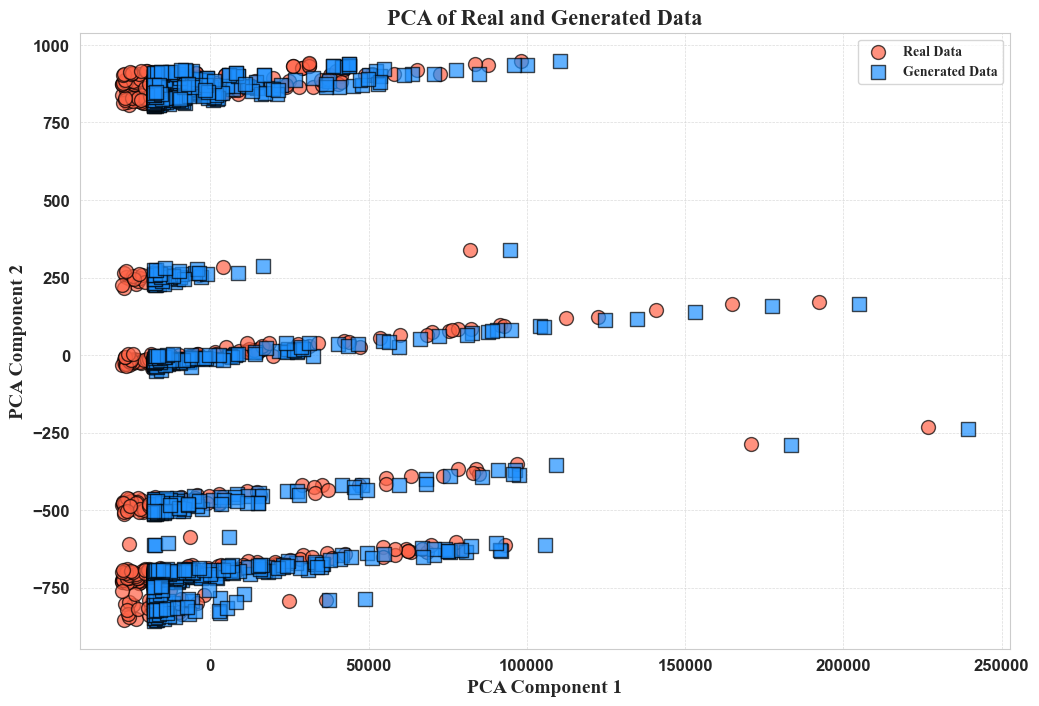

In [13]:
# 配置 Matplotlib 以使用 Times New Roman 和 Arial 字体
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Times New Roman'
rcParams['mathtext.it'] = 'Times New Roman:italic'
rcParams['mathtext.bf'] = 'Times New Roman:bold'

# 读取数据
generated_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
real_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

# 确保数据中没有缺失值，并将数据标准化（这一步可能需要根据具体数据情况调整）
generated_data = generated_data.dropna()
real_data = real_data.dropna()

# 选择需要进行PCA的特征列（假设所有列都是特征）
features_generated = generated_data.iloc[:, :]
features_real = real_data.iloc[:, :]

# PCA降维到2维
pca = PCA(n_components=2)
pca_result_generated = pca.fit_transform(features_generated)
pca_result_real = pca.fit_transform(features_real)

# 将PCA结果转换为DataFrame
pca_df_generated = pd.DataFrame(pca_result_generated, columns=['PCA1', 'PCA2'])
pca_df_real = pd.DataFrame(pca_result_real, columns=['PCA1', 'PCA2'])

# 绘制散点图
plt.figure(figsize=(12, 8))

plt.scatter(pca_df_real['PCA1'], pca_df_real['PCA2'], color='#FF6347', edgecolor='k', label='Real Data', alpha=0.7, s=100, marker='o')
plt.scatter(pca_df_generated['PCA1'], pca_df_generated['PCA2'], color='#1E90FF', edgecolor='k', label='Generated Data', alpha=0.7, s=100, marker='s')

# 添加标题和标签
plt.xlabel('PCA Component 1', fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel('PCA Component 2', fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.title('PCA of Real and Generated Data', fontsize=16, fontweight='bold', fontname='Times New Roman')

# 调整图例位置和样式
plt.legend(loc='upper right', fancybox=True, prop={'family': 'Times New Roman'})

# 美化坐标轴
plt.xticks(fontsize=12, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=12, fontname='Arial', fontweight='bold')

# 添加网格线
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# 保存图片
plt.savefig('PCAcomparison_plot.pdf', format='pdf')
plt.savefig('PCAcomparison_plot.png', format='png')

# 显示图形
plt.show()

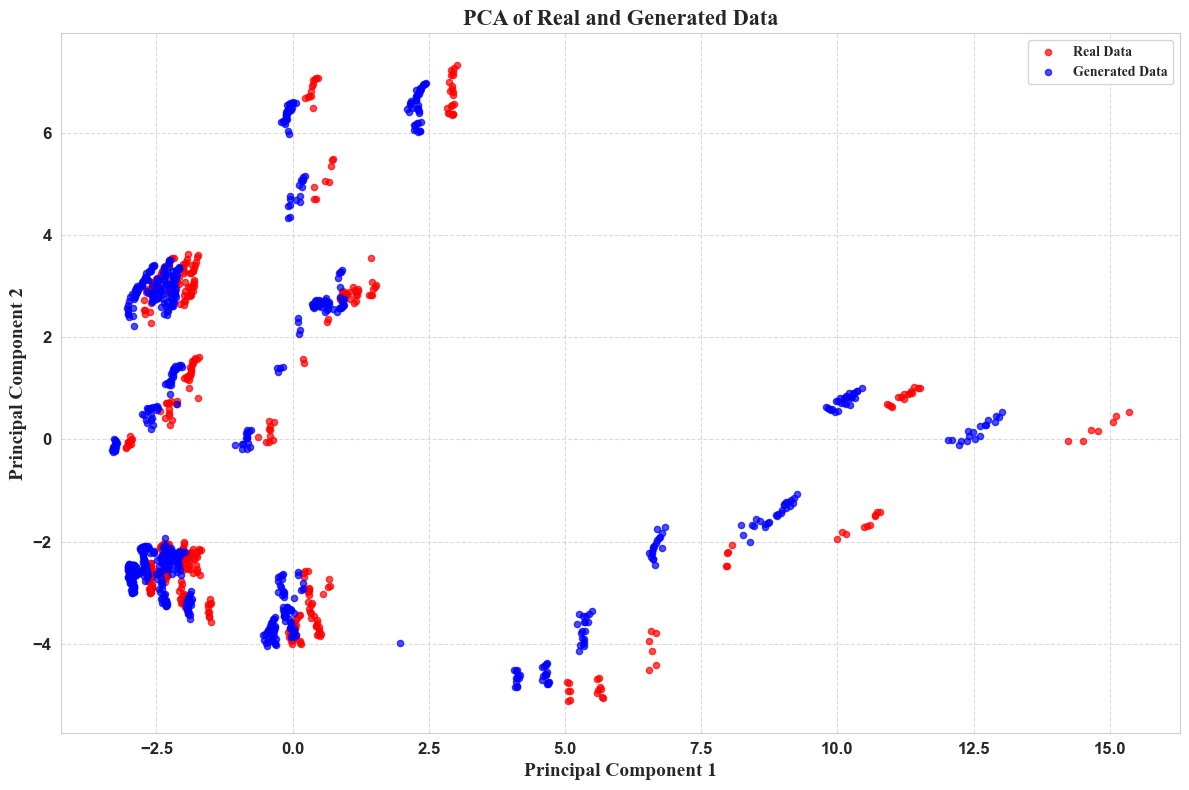

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import rcParams

# 配置 Matplotlib 以使用 Times New Roman 和 Arial 字体
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Times New Roman'
rcParams['mathtext.it'] = 'Times New Roman:italic'
rcParams['mathtext.bf'] = 'Times New Roman:bold'

# 读取数据
generated_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
real_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

# 确保数据中没有缺失值，并将数据标准化（这一步可能需要根据具体数据情况调整）
generated_data = generated_data.dropna()
real_data = real_data.dropna()

# 标准化数据
scaler = StandardScaler()
X_generated_scaled = scaler.fit_transform(generated_data)
X_real_scaled = scaler.fit_transform(real_data)

# 使用PCA降维
pca = PCA(n_components=2)
X_real_pca = pca.fit_transform(X_real_scaled)
X_generated_pca = pca.transform(X_generated_scaled)

# 可视化
plt.figure(figsize=(12, 8))
plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], c='red', s=20, alpha=0.7, label='Real Data')
plt.scatter(X_generated_pca[:, 0], X_generated_pca[:, 1], c='blue', s=20, alpha=0.7, label='Generated Data')

# 添加标题和标签
plt.title('PCA of Real and Generated Data', fontsize=16, fontname='Times New Roman', fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=14, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Principal Component 2', fontsize=14, fontname='Times New Roman', fontweight='bold')
plt.legend(fontsize=12, prop={'family': 'Times New Roman', 'weight': 'bold'})

# 美化坐标轴
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=12, fontname='Arial', fontweight='bold')

plt.tight_layout()

# 保存图片
plt.savefig('pca_generated_real_data.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('pca__generated_real_data.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

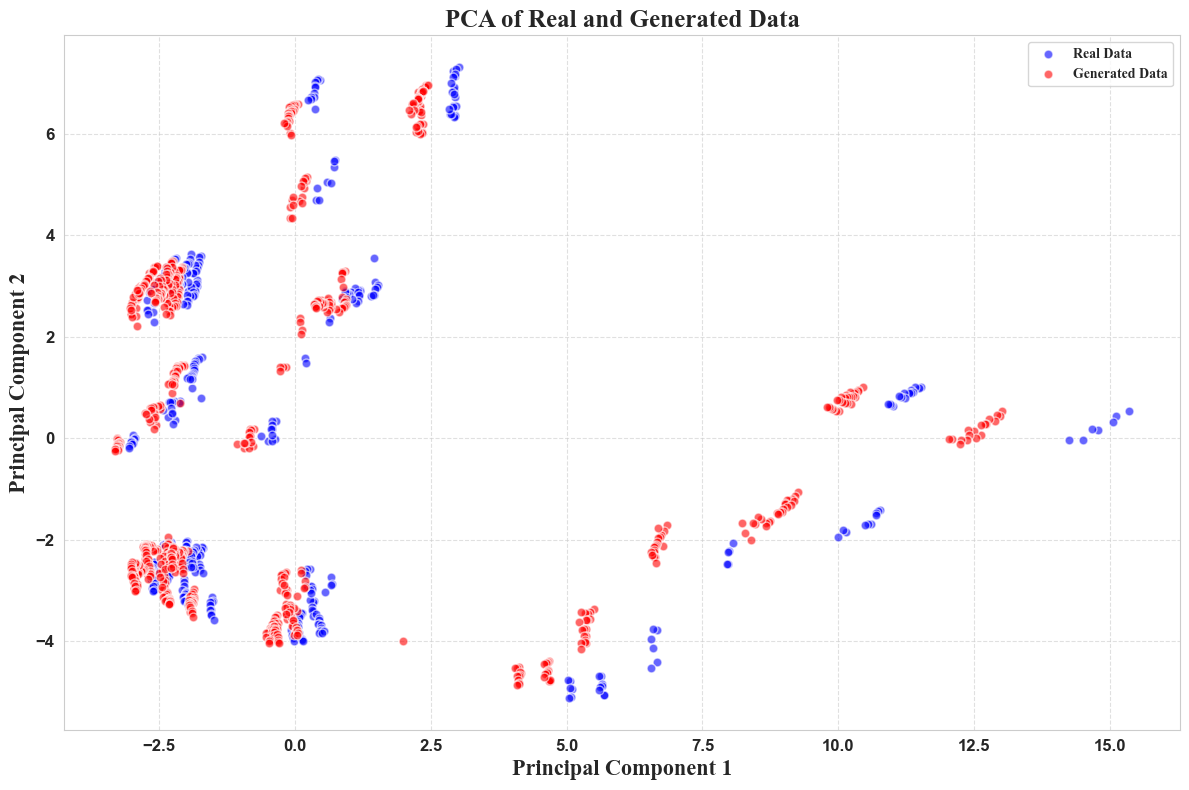

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import rcParams

# 配置 Matplotlib 以使用 Times New Roman 和 Arial 字体
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Times New Roman'
rcParams['mathtext.it'] = 'Times New Roman:italic'
rcParams['mathtext.bf'] = 'Times New Roman:bold'

# 读取数据
generated_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
real_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

# 确保数据中没有缺失值，并将数据标准化（这一步可能需要根据具体数据情况调整）
generated_data = generated_data.dropna()
real_data = real_data.dropna()

# 标准化数据
scaler = StandardScaler()
X_generated_scaled = scaler.fit_transform(generated_data)
X_real_scaled = scaler.fit_transform(real_data)

# 使用PCA降维
pca = PCA(n_components=2)
X_real_pca = pca.fit_transform(X_real_scaled)
X_generated_pca = pca.transform(X_generated_scaled)

# 可视化
plt.figure(figsize=(12, 8))
plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], c='blue', s=40, alpha=0.6, edgecolor='w', label='Real Data')
plt.scatter(X_generated_pca[:, 0], X_generated_pca[:, 1], c='red', s=40, alpha=0.6, edgecolor='w', label='Generated Data')

# 添加标题和标签
plt.title('PCA of Real and Generated Data', fontsize=18, fontname='Times New Roman', fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=16, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Principal Component 2', fontsize=16, fontname='Times New Roman', fontweight='bold')
plt.legend(fontsize=14, prop={'family': 'Times New Roman', 'weight': 'bold'}, loc='upper right')

# 美化坐标轴
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=12, fontname='Arial', fontweight='bold')

plt.tight_layout()

# 保存图片
plt.savefig('pca_generated_real_data_beautified.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('pca_generated_real_data_beautified.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import rcParams

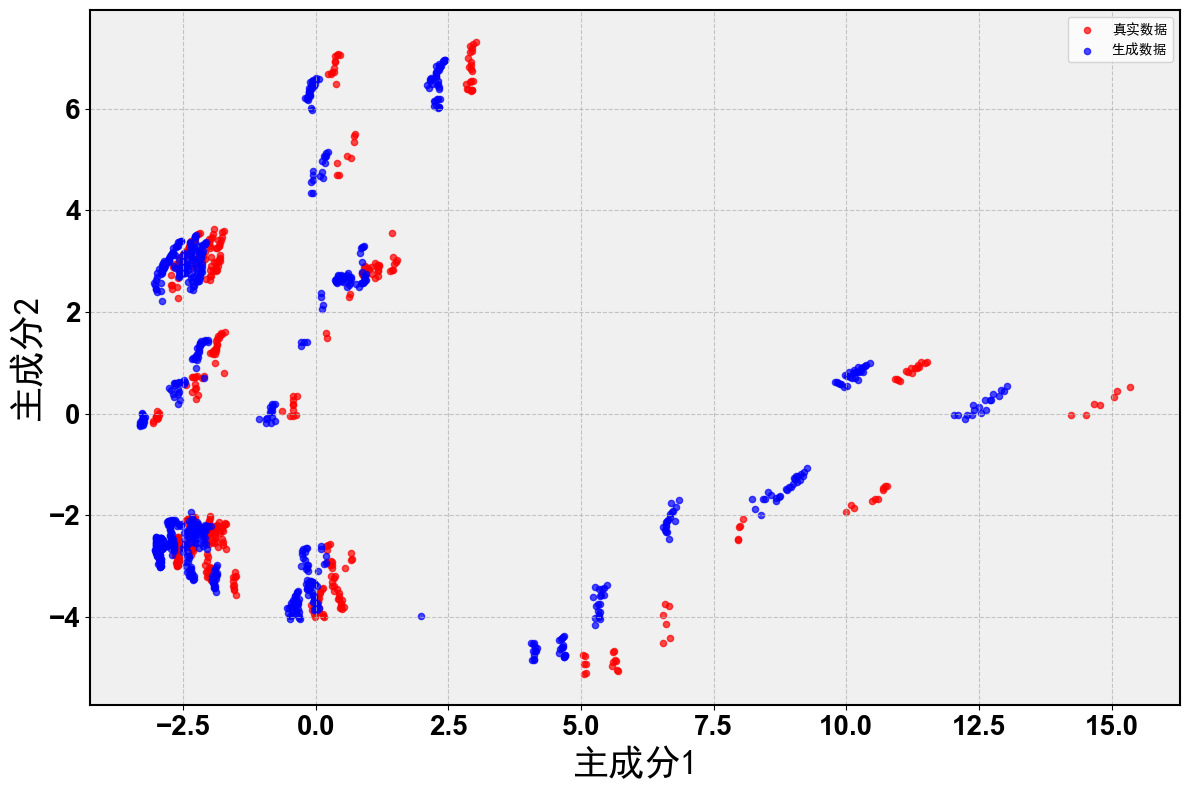

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 配置 Matplotlib 以使用 Times New Roman 和 Arial 字体
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

# 读取数据
generated_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
real_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

# 确保数据中没有缺失值，并将数据标准化（这一步可能需要根据具体数据情况调整）
generated_data = generated_data.dropna()
real_data = real_data.dropna()

# 标准化数据
scaler = StandardScaler()
X_generated_scaled = scaler.fit_transform(generated_data)
X_real_scaled = scaler.fit_transform(real_data)

# 使用PCA降维
pca = PCA(n_components=2)
X_real_pca = pca.fit_transform(X_real_scaled)
X_generated_pca = pca.transform(X_generated_scaled)

# 可视化
plt.figure(figsize=(12, 8))

# 设置图表背景颜色
plt.gca().set_facecolor('#f0f0f0')  # 很淡的灰色背景

plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], c='red', s=20, alpha=0.7, label='真实数据')
plt.scatter(X_generated_pca[:, 0], X_generated_pca[:, 1], c='blue', s=20, alpha=0.7, label='生成数据')

# 设置图标边框为黑色
ax = plt.gca()
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# 添加中文标题和标签
plt.xlabel('主成分1', fontsize=26, fontname='SimHei', fontweight='bold')
plt.ylabel('主成分2', fontsize=26, fontname='SimHei', fontweight='bold')
plt.legend(fontsize=30, prop={'family': 'SimHei', 'weight': 'bold'})

# 美化坐标轴
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=20, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=20, fontname='Arial', fontweight='bold')

plt.tight_layout()

# 保存图片
plt.savefig('蠕变PCA.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('蠕变PCA.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

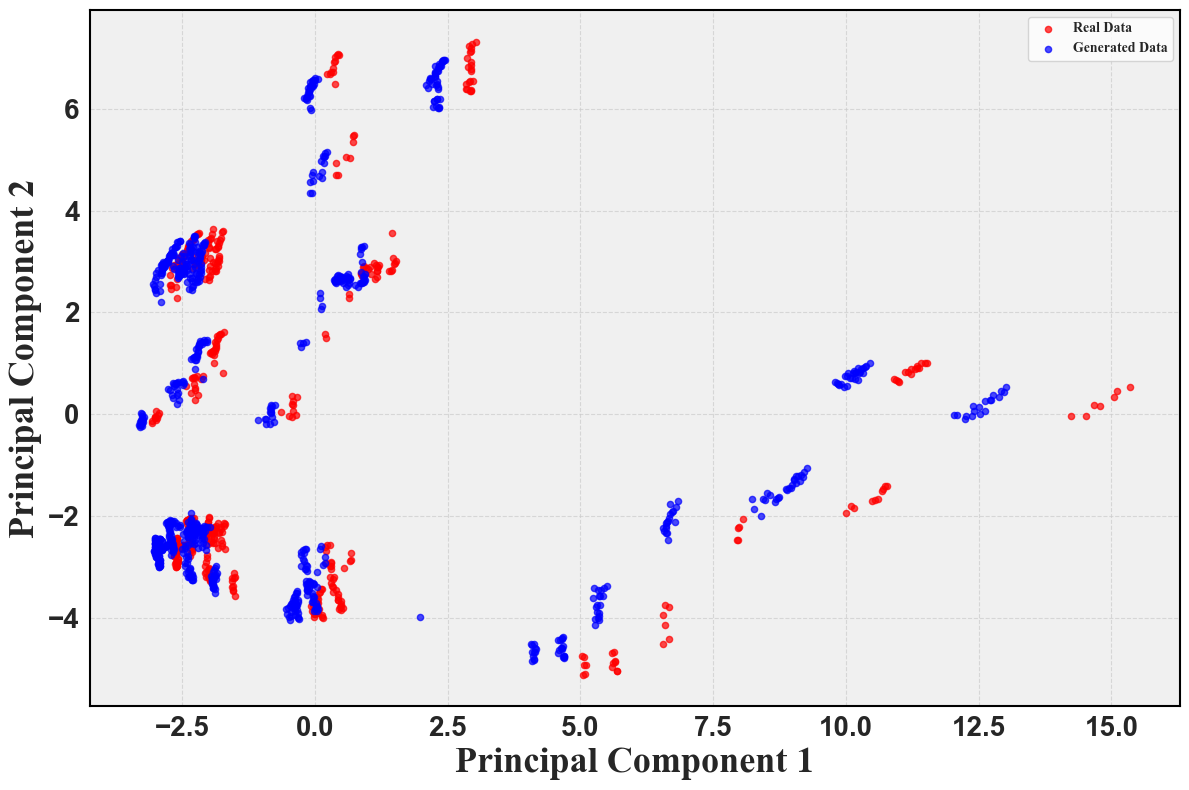

In [21]:


# 配置 Matplotlib 以使用 Times New Roman 和 Arial 字体
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Times New Roman']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Times New Roman'
rcParams['mathtext.it'] = 'Times New Roman:italic'
rcParams['mathtext.bf'] = 'Times New Roman:bold'

# 读取数据
generated_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
real_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

# 确保数据中没有缺失值，并将数据标准化（这一步可能需要根据具体数据情况调整）
generated_data = generated_data.dropna()
real_data = real_data.dropna()

# 标准化数据
scaler = StandardScaler()
X_generated_scaled = scaler.fit_transform(generated_data)
X_real_scaled = scaler.fit_transform(real_data)

# 使用PCA降维
pca = PCA(n_components=2)
X_real_pca = pca.fit_transform(X_real_scaled)
X_generated_pca = pca.transform(X_generated_scaled)

# 可视化
plt.figure(figsize=(12, 8))

# 设置图表背景颜色
plt.gca().set_facecolor('#f0f0f0')  # 很淡的灰色背景

plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], c='red', s=20, alpha=0.7, label='Real Data')
plt.scatter(X_generated_pca[:, 0], X_generated_pca[:, 1], c='blue', s=20, alpha=0.7, label='Generated Data')
# 设置图标边框为黑色
ax = plt.gca()
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# 添加标题和标签
plt.xlabel('Principal Component 1', fontsize=26, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Principal Component 2', fontsize=26, fontname='Times New Roman', fontweight='bold')
plt.legend(fontsize=30, prop={'family': 'Times New Roman', 'weight': 'bold'})

# 美化坐标轴
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=20, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=20, fontname='Arial', fontweight='bold')

plt.tight_layout()

# 保存图片
plt.savefig('pca_generated_real_data.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('pca_generated_real_data.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

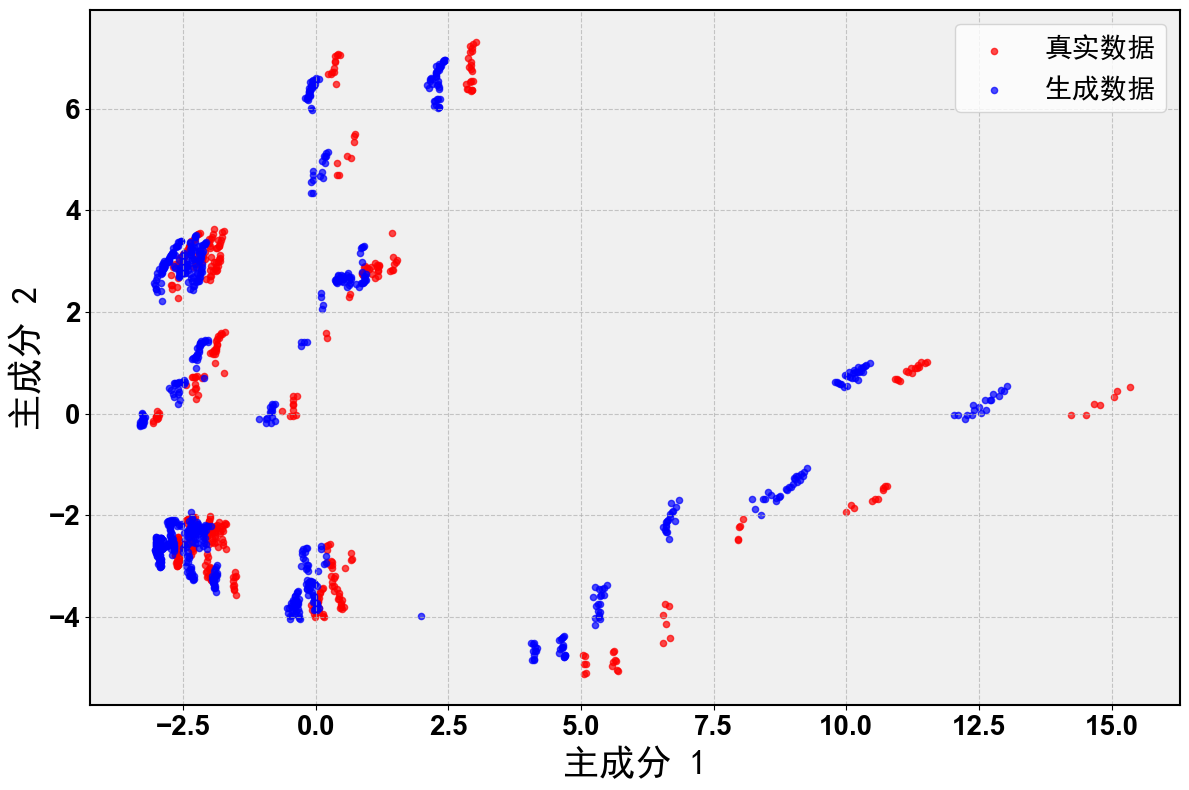

In [4]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.font_manager import FontProperties

# 配置 Matplotlib 以使用中文字体
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['SimHei']  # 使用中文字体
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'SimHei'  # 使用中文字体
rcParams['mathtext.it'] = 'SimHei:italic'
rcParams['mathtext.bf'] = 'SimHei:bold'

# 读取数据
generated_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
real_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

# 确保数据中没有缺失值，并将数据标准化（这一步可能需要根据具体数据情况调整）
generated_data = generated_data.dropna()
real_data = real_data.dropna()

# 标准化数据
scaler = StandardScaler()
X_generated_scaled = scaler.fit_transform(generated_data)
X_real_scaled = scaler.fit_transform(real_data)

# 使用PCA降维
pca = PCA(n_components=2)
X_real_pca = pca.fit_transform(X_real_scaled)
X_generated_pca = pca.transform(X_generated_scaled)

# 可视化
plt.figure(figsize=(12, 8))

# 设置图表背景颜色
plt.gca().set_facecolor('#f0f0f0')  # 很淡的灰色背景

plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], c='red', s=20, alpha=0.7, label='真实数据')
plt.scatter(X_generated_pca[:, 0], X_generated_pca[:, 1], c='blue', s=20, alpha=0.7, label='生成数据')

# 设置图标边框为黑色
ax = plt.gca()
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# 添加标题和标签
plt.xlabel('主成分 1', fontsize=26, fontname='SimHei', fontweight='bold')
plt.ylabel('主成分 2', fontsize=26, fontname='SimHei', fontweight='bold')

# 创建一个FontProperties对象
fontP = FontProperties()
fontP.set_size('20')
fontP.set_family('SimHei')
fontP.set_weight('bold')

plt.legend(prop=fontP)  # 调整图例字体大小和风格

# 美化坐标轴
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=20, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=20, fontname='Arial', fontweight='bold')

plt.tight_layout()

# 保存图片
plt.savefig('蠕变PCA.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('蠕变PCA.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

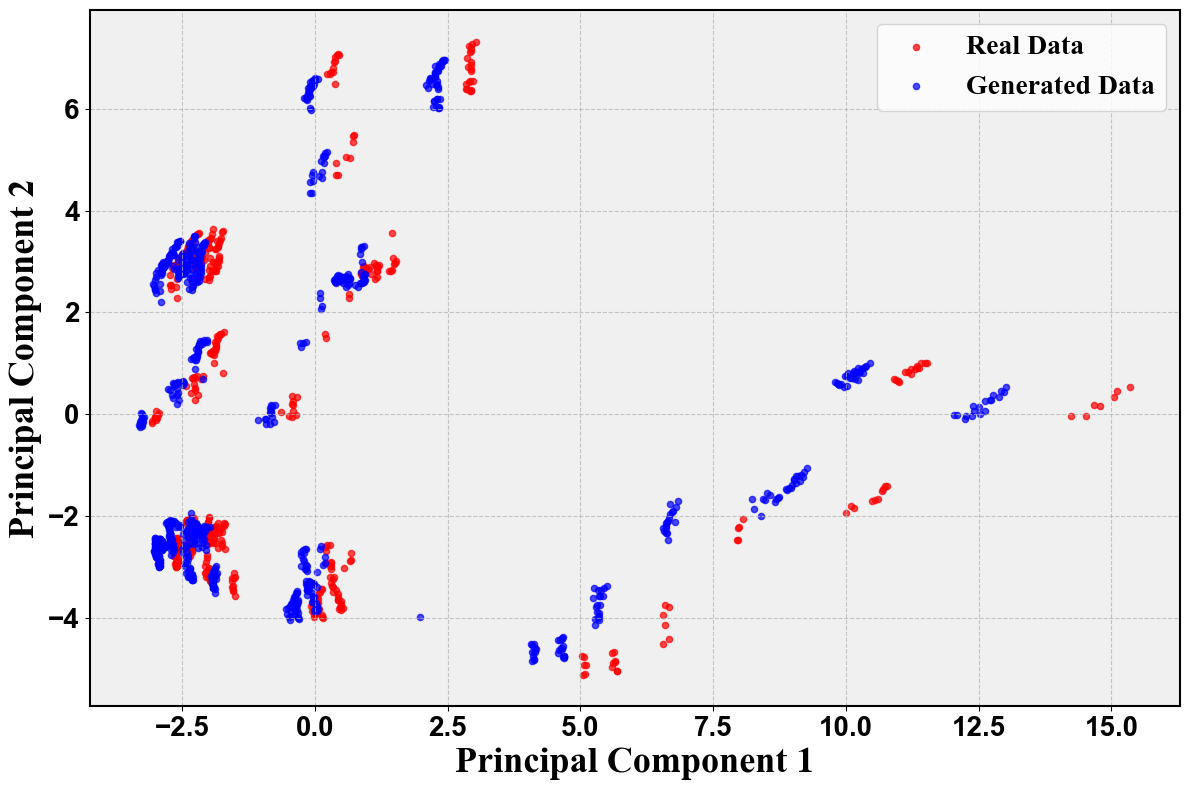

In [7]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.font_manager import FontProperties

# 配置 Matplotlib 以使用 Times New Roman 和 Arial 字体
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Times New Roman']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Times New Roman'
rcParams['mathtext.it'] = 'Times New Roman:italic'
rcParams['mathtext.bf'] = 'Times New Roman:bold'

# 读取数据
generated_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
real_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

# 确保数据中没有缺失值，并将数据标准化（这一步可能需要根据具体数据情况调整）
generated_data = generated_data.dropna()
real_data = real_data.dropna()

# 标准化数据
scaler = StandardScaler()
X_generated_scaled = scaler.fit_transform(generated_data)
X_real_scaled = scaler.fit_transform(real_data)

# 使用PCA降维
pca = PCA(n_components=2)
X_real_pca = pca.fit_transform(X_real_scaled)
X_generated_pca = pca.transform(X_generated_scaled)

# 可视化
plt.figure(figsize=(12, 8))

# 设置图表背景颜色
plt.gca().set_facecolor('#f0f0f0')  # 很淡的灰色背景

plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], c='red', s=20, alpha=0.7, label='Real Data')
plt.scatter(X_generated_pca[:, 0], X_generated_pca[:, 1], c='blue', s=20, alpha=0.7, label='Generated Data')

# 设置图标边框为黑色
ax = plt.gca()
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# 添加标题和标签
plt.xlabel('Principal Component 1', fontsize=26, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Principal Component 2', fontsize=26, fontname='Times New Roman', fontweight='bold')

# 创建一个FontProperties对象
fontP = FontProperties()
fontP.set_size('20')
fontP.set_family('Times New Roman')
fontP.set_weight('bold')

plt.legend(prop=fontP)  # 调整图例字体大小和风格

# 美化坐标轴
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=20, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=20, fontname='Arial', fontweight='bold')

plt.tight_layout()

# 保存图片
plt.savefig('pca_generated_real_data.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('pca_generated_real_data.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

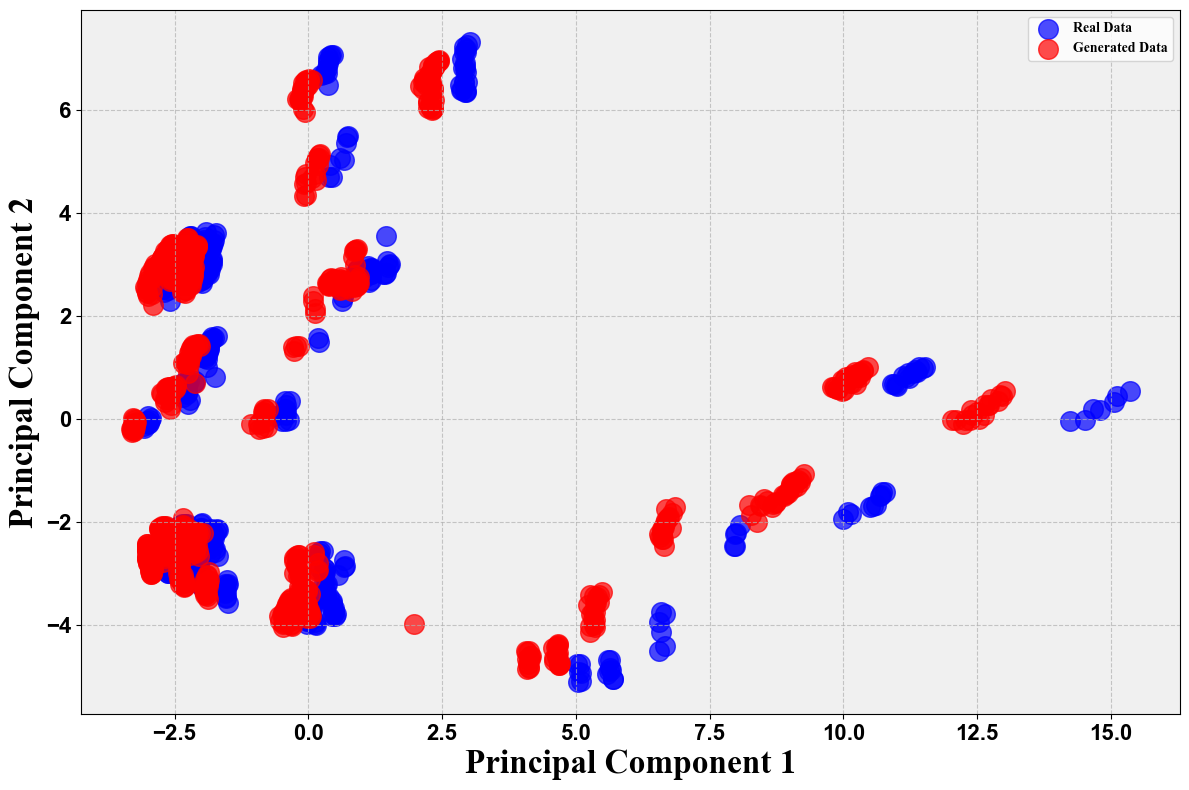

In [7]:
# 配置 Matplotlib 以使用 Times New Roman 和 Arial 字体
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Times New Roman'
rcParams['mathtext.it'] = 'Times New Roman:italic'
rcParams['mathtext.bf'] = 'Times New Roman:bold'

# 读取数据
generated_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TRAugmentation.xlsx')
real_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\TR大于2500.xlsx')

# 确保数据中没有缺失值，并将数据标准化（这一步可能需要根据具体数据情况调整）
generated_data = generated_data.dropna()
real_data = real_data.dropna()

# 标准化数据
scaler = StandardScaler()
X_generated_scaled = scaler.fit_transform(generated_data)
X_real_scaled = scaler.fit_transform(real_data)

# 使用PCA降维
pca = PCA(n_components=2)
X_real_pca = pca.fit_transform(X_real_scaled)
X_generated_pca = pca.transform(X_generated_scaled)

# 可视化
plt.figure(figsize=(12, 8))

# 设置图表背景颜色
plt.gca().set_facecolor('#f0f0f0')  # 很淡的灰色背景

plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], c='blue', s=200, alpha=0.7, label='Real Data')
plt.scatter(X_generated_pca[:, 0], X_generated_pca[:, 1], c='red', s=200, alpha=0.7, label='Generated Data')

# 添加标题和标签
plt.xlabel('Principal Component 1', fontsize=24, fontname='Times New Roman', fontweight='bold')
plt.ylabel('Principal Component 2', fontsize=24, fontname='Times New Roman', fontweight='bold')
plt.legend(fontsize=16, prop={'family': 'Times New Roman', 'weight': 'bold'})

# 美化坐标轴
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=16, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=16, fontname='Arial', fontweight='bold')

plt.tight_layout()

# 保存图片
plt.savefig('pca_generated_real_data.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('pca_generated_real_data.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
from PIL import Image, ImageDraw, ImageFont

# 打开两张图片
image1 = Image.open('核密度分布comparison_plot.png')
image2 = Image.open('pca_generated_real_data.png')

# 获取图片的宽度和高度
width1, height1 = image1.size
width2, height2 = image2.size

# 创建一个新的图像，宽度是两张图片的宽度之和，高度是最大的图片高度
combined_width = width1 + width2
combined_height = max(height1, height2)
combined_image = Image.new('RGB', (combined_width, combined_height), (255, 255, 255))

# 将两张图片粘贴到新的图像上
combined_image.paste(image1, (0, 0))
combined_image.paste(image2, (width1, 0))

# 添加标注
draw = ImageDraw.Draw(combined_image)
font = ImageFont.truetype("arial.ttf", 40)

# 在左上角添加(a)
draw.text((10, 10), "(a)", fill="black", font=font)

# 在第二张图片的左上角添加(b)
draw.text((width1 + 10, 10), "(b)", fill="black", font=font)

# 保存合并后的图片
combined_image.save('combined_image.png')

combined_image.show()

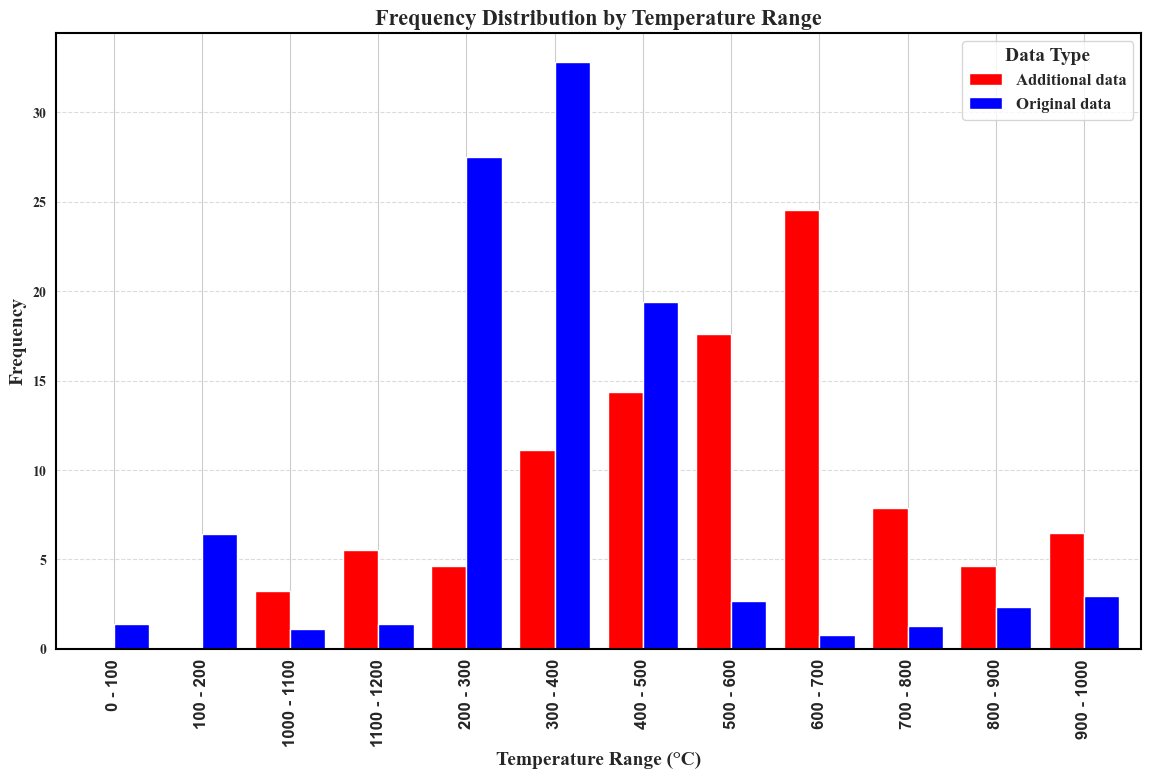

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate your data as a list of lists
data = [
    ['Additional data', '0 - 100', 0],
    ['Additional data', '100 - 200', 0],
    ['Additional data', '200 - 300', 4.62963],
    ['Additional data', '300 - 400', 11.11111],
    ['Additional data', '400 - 500', 14.35185],
    ['Additional data', '500 - 600', 17.59259],
    ['Additional data', '600 - 700', 24.53704],
    ['Additional data', '700 - 800', 7.87037],
    ['Additional data', '800 - 900', 4.62963],
    ['Additional data', '900 - 1000', 6.48148],
    ['Additional data', '1000 - 1100', 3.24074],
    ['Additional data', '1100 - 1200', 5.55556],
    ['Original data', '0 - 100', 1.40625],
    ['Original data', '100 - 200', 6.40625],
    ['Original data', '200 - 300', 27.5],
    ['Original data', '300 - 400', 32.8125],
    ['Original data', '400 - 500', 19.375],
    ['Original data', '500 - 600', 2.65625],
    ['Original data', '600 - 700', 0.78125],
    ['Original data', '700 - 800', 1.25],
    ['Original data', '800 - 900', 2.34375],
    ['Original data', '900 - 1000', 2.96875],
    ['Original data', '1000 - 1100', 1.09375],
    ['Original data', '1100 - 1200', 1.40625]
]

# Create DataFrame
df = pd.DataFrame(data, columns=['Data Type', 'Temperature Range', 'Frequency'])

# Pivot the data to have temperature ranges as index and data types as columns
df_pivot = df.pivot(index='Temperature Range', columns='Data Type', values='Frequency').fillna(0)

# Plot the data
ax = df_pivot.plot(kind='bar', figsize=(14, 8), width=0.8, color=['red', 'blue'])

# Set the labels and title
plt.xlabel('Temperature Range (°C)', fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel('Frequency', fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.title('Frequency Distribution by Temperature Range', fontsize=16, fontweight='bold', fontname='Times New Roman')

# Customize the legend
plt.legend(title='Data Type', fontsize=12, title_fontsize=14)

# Customize the grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set x-ticks font
plt.xticks(fontsize=12, fontname='Arial', fontweight='bold')

# Customize the plot spines
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# Save the plot
plt.savefig('frequency_distribution_by_temperature_range.pdf', format='pdf')
plt.savefig('frequency_distribution_by_temperature_range.png', format='png')

# Show the plot
plt.show()

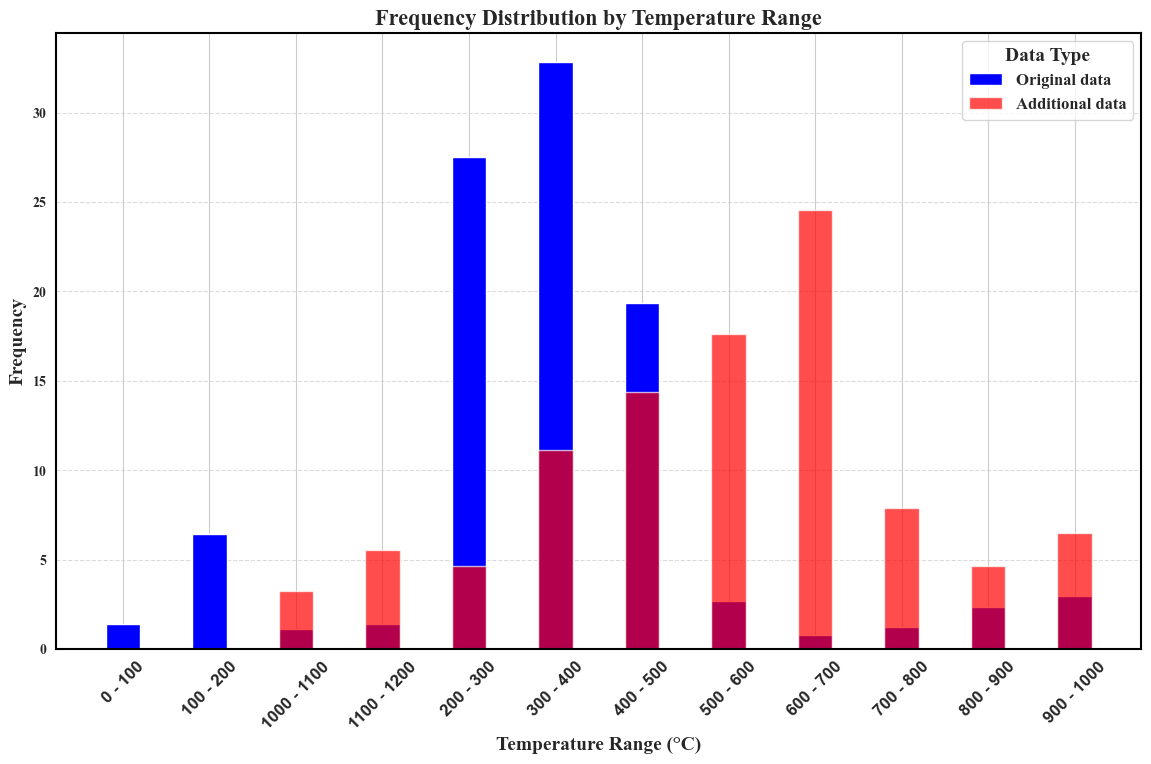

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate your data as a list of lists
data = [
    ['Additional data', '0 - 100', 0],
    ['Additional data', '100 - 200', 0],
    ['Additional data', '200 - 300', 4.62963],
    ['Additional data', '300 - 400', 11.11111],
    ['Additional data', '400 - 500', 14.35185],
    ['Additional data', '500 - 600', 17.59259],
    ['Additional data', '600 - 700', 24.53704],
    ['Additional data', '700 - 800', 7.87037],
    ['Additional data', '800 - 900', 4.62963],
    ['Additional data', '900 - 1000', 6.48148],
    ['Additional data', '1000 - 1100', 3.24074],
    ['Additional data', '1100 - 1200', 5.55556],
    ['Original data', '0 - 100', 1.40625],
    ['Original data', '100 - 200', 6.40625],
    ['Original data', '200 - 300', 27.5],
    ['Original data', '300 - 400', 32.8125],
    ['Original data', '400 - 500', 19.375],
    ['Original data', '500 - 600', 2.65625],
    ['Original data', '600 - 700', 0.78125],
    ['Original data', '700 - 800', 1.25],
    ['Original data', '800 - 900', 2.34375],
    ['Original data', '900 - 1000', 2.96875],
    ['Original data', '1000 - 1100', 1.09375],
    ['Original data', '1100 - 1200', 1.40625]
]

# Create DataFrame
df = pd.DataFrame(data, columns=['Data Type', 'Temperature Range', 'Frequency'])

# Pivot the data to have temperature ranges as index and data types as columns
df_pivot = df.pivot(index='Temperature Range', columns='Data Type', values='Frequency').fillna(0)

# Plot the data
fig, ax = plt.subplots(figsize=(14, 8))

# Set bar width
bar_width = 0.4

# Create bar positions
positions = range(len(df_pivot))

# Plot "Original data"
bars1 = ax.bar(positions, df_pivot['Original data'], width=bar_width, color='blue', label='Original data')

# Plot "Additional data" on top with transparency
bars2 = ax.bar(positions, df_pivot['Additional data'], width=bar_width, color='red', label='Additional data', alpha=0.7)

# Set the labels and title
ax.set_xlabel('Temperature Range (°C)', fontsize=14, fontweight='bold', fontname='Times New Roman')
ax.set_ylabel('Frequency', fontsize=14, fontweight='bold', fontname='Times New Roman')
ax.set_title('Frequency Distribution by Temperature Range', fontsize=16, fontweight='bold', fontname='Times New Roman')

# Set x-ticks
ax.set_xticks(positions)
ax.set_xticklabels(df_pivot.index, fontsize=12, fontname='Arial', fontweight='bold', rotation=45)

# Customize the legend
ax.legend(title='Data Type', fontsize=12, title_fontsize=14)

# Customize the grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Customize the plot spines
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# Save the plot
plt.savefig('frequency_distribution_by_temperature_range_overlay.pdf', format='pdf')
plt.savefig('frequency_distribution_by_temperature_range_overlay.png', format='png')

# Show the plot
plt.show()

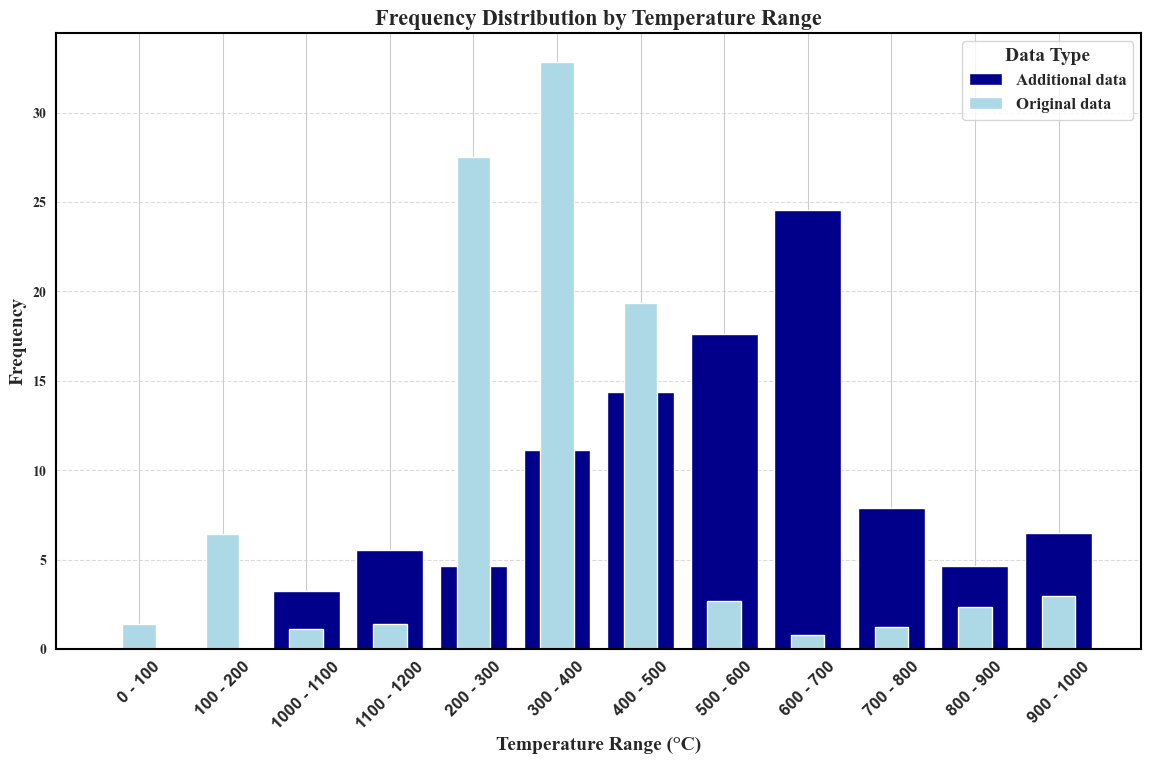

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate your data as a list of lists
data = [
    ['Additional data', '0 - 100', 0],
    ['Additional data', '100 - 200', 0],
    ['Additional data', '200 - 300', 4.62963],
    ['Additional data', '300 - 400', 11.11111],
    ['Additional data', '400 - 500', 14.35185],
    ['Additional data', '500 - 600', 17.59259],
    ['Additional data', '600 - 700', 24.53704],
    ['Additional data', '700 - 800', 7.87037],
    ['Additional data', '800 - 900', 4.62963],
    ['Additional data', '900 - 1000', 6.48148],
    ['Additional data', '1000 - 1100', 3.24074],
    ['Additional data', '1100 - 1200', 5.55556],
    ['Original data', '0 - 100', 1.40625],
    ['Original data', '100 - 200', 6.40625],
    ['Original data', '200 - 300', 27.5],
    ['Original data', '300 - 400', 32.8125],
    ['Original data', '400 - 500', 19.375],
    ['Original data', '500 - 600', 2.65625],
    ['Original data', '600 - 700', 0.78125],
    ['Original data', '700 - 800', 1.25],
    ['Original data', '800 - 900', 2.34375],
    ['Original data', '900 - 1000', 2.96875],
    ['Original data', '1000 - 1100', 1.09375],
    ['Original data', '1100 - 1200', 1.40625]
]

# Create DataFrame
df = pd.DataFrame(data, columns=['Data Type', 'Temperature Range', 'Frequency'])

# Pivot the data to have temperature ranges as index and data types as columns
df_pivot = df.pivot(index='Temperature Range', columns='Data Type', values='Frequency').fillna(0)

# Plot the data
fig, ax = plt.subplots(figsize=(14, 8))

# Set bar width
bar_width_outer = 0.8
bar_width_inner = 0.4

# Create bar positions
positions = range(len(df_pivot))

# Plot "Additional data"
bars1 = ax.bar(positions, df_pivot['Additional data'], width=bar_width_outer, color='darkblue', label='Additional data')

# Plot "Original data" inside "Additional data" bars
bars2 = ax.bar(positions, df_pivot['Original data'], width=bar_width_inner, color='lightblue', label='Original data')

# Set the labels and title
ax.set_xlabel('Temperature Range (°C)', fontsize=14, fontweight='bold', fontname='Times New Roman')
ax.set_ylabel('Frequency', fontsize=14, fontweight='bold', fontname='Times New Roman')
ax.set_title('Frequency Distribution by Temperature Range', fontsize=16, fontweight='bold', fontname='Times New Roman')

# Set x-ticks
ax.set_xticks(positions)
ax.set_xticklabels(df_pivot.index, fontsize=12, fontname='Arial', fontweight='bold', rotation=45)

# Customize the legend
ax.legend(title='Data Type', fontsize=12, title_fontsize=14)

# Customize the grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Customize the plot spines
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# Save the plot
plt.savefig('frequency_distribution_by_temperature_range_nested.pdf', format='pdf')
plt.savefig('frequency_distribution_by_temperature_range_nested.png', format='png')

# Show the plot
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_6732\3425891604.py:65: MatplotlibDeprecationWarning: The label function was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use Tick.label1 instead.
  tick.label.set_fontname('Times New Roman')


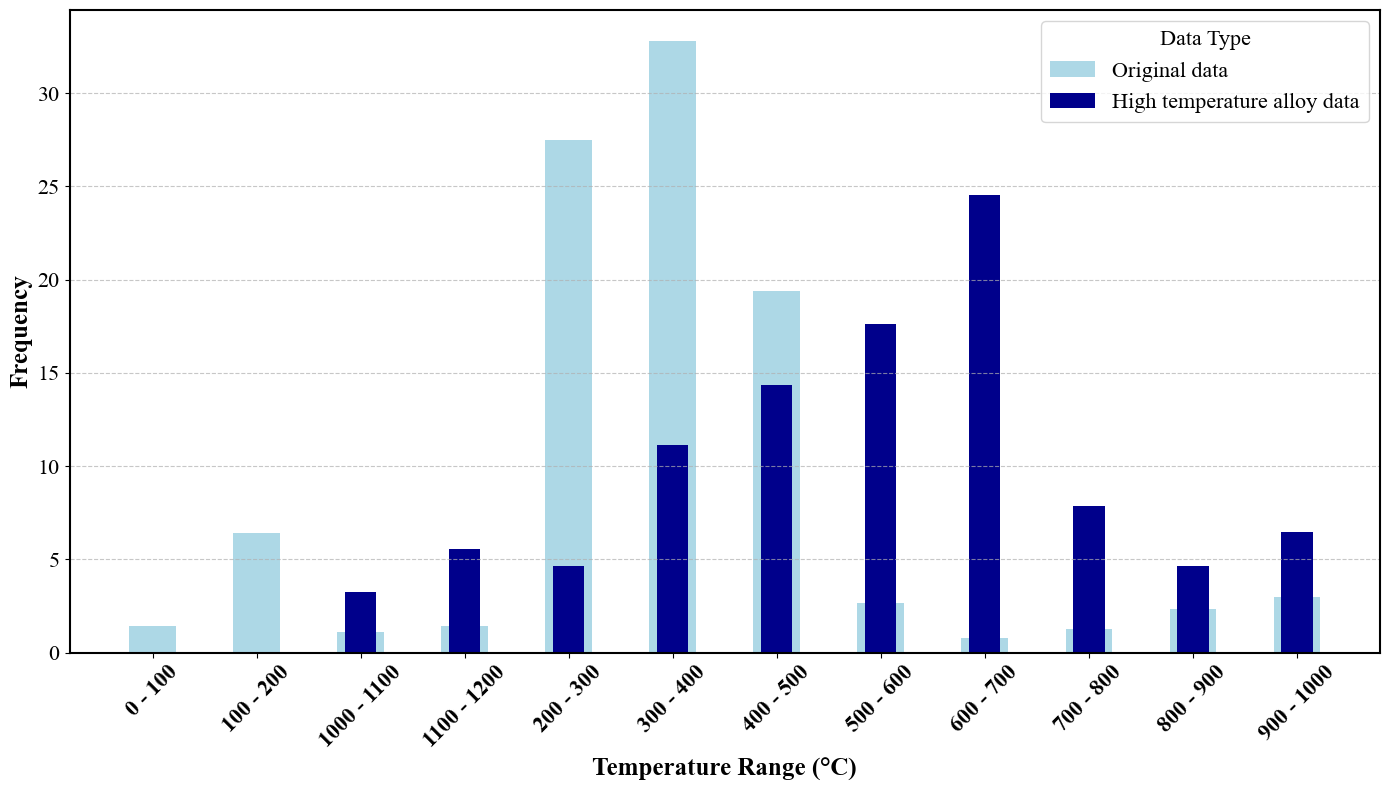

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate your data as a list of lists
data = [
    ['Additional data', '0 - 100', 0],
    ['Additional data', '100 - 200', 0],
    ['Additional data', '200 - 300', 4.62963],
    ['Additional data', '300 - 400', 11.11111],
    ['Additional data', '400 - 500', 14.35185],
    ['Additional data', '500 - 600', 17.59259],
    ['Additional data', '600 - 700', 24.53704],
    ['Additional data', '700 - 800', 7.87037],
    ['Additional data', '800 - 900', 4.62963],
    ['Additional data', '900 - 1000', 6.48148],
    ['Additional data', '1000 - 1100', 3.24074],
    ['Additional data', '1100 - 1200', 5.55556],
    ['Original data', '0 - 100', 1.40625],
    ['Original data', '100 - 200', 6.40625],
    ['Original data', '200 - 300', 27.5],
    ['Original data', '300 - 400', 32.8125],
    ['Original data', '400 - 500', 19.375],
    ['Original data', '500 - 600', 2.65625],
    ['Original data', '600 - 700', 0.78125],
    ['Original data', '700 - 800', 1.25],
    ['Original data', '800 - 900', 2.34375],
    ['Original data', '900 - 1000', 2.96875],
    ['Original data', '1000 - 1100', 1.09375],
    ['Original data', '1100 - 1200', 1.40625]
]

# Create DataFrame
df = pd.DataFrame(data, columns=['Data Type', 'Temperature Range', 'Frequency'])

# Pivot the data to have temperature ranges as index and data types as columns
df_pivot = df.pivot(index='Temperature Range', columns='Data Type', values='Frequency').fillna(0)

# Plot the data
fig, ax = plt.subplots(figsize=(14, 8))

# Set bar width
bar_width_outer = 0.45
bar_width_inner = 0.3

# Create bar positions
positions = range(len(df_pivot))

# Plot "Original data" with wider bars
bars1 = ax.bar(positions, df_pivot['Original data'], width=bar_width_outer, color='lightblue', label='Original data')

# Plot "Additional data" inside "Original data" bars with narrower width
bars2 = ax.bar(positions, df_pivot['Additional data'], width=bar_width_inner, color='darkblue', label='High temperature alloy data')

# Set the labels and title
ax.set_xlabel('Temperature Range (°C)', fontsize=18, fontweight='bold', fontname='Times New Roman')
ax.set_ylabel('Frequency', fontsize=18, fontweight='bold', fontname='Times New Roman')

# Set x-ticks
ax.set_xticks(positions)
ax.set_xticklabels(df_pivot.index, fontsize=16, fontname='Times New Roman', fontweight='bold', rotation=45)

# Customize the y-tick labels
ax.yaxis.set_tick_params(labelsize=16)
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontname('Times New Roman')

# Customize the legend
ax.legend(title='Data Type', fontsize=16, title_fontsize=16)

# Customize the grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Customize the plot spines
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# Adjust layout to ensure everything fits
plt.tight_layout()

# Save the plot
plt.savefig('frequency_distribution_by_temperature_range_nested_reverse.pdf', format='pdf')
plt.savefig('frequency_distribution_by_temperature_range_nested_reverse.png', format='png')

# Show the plot
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_6732\3217589221.py:65: MatplotlibDeprecationWarning: The label function was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use Tick.label1 instead.
  tick.label.set_fontname('Times New Roman')


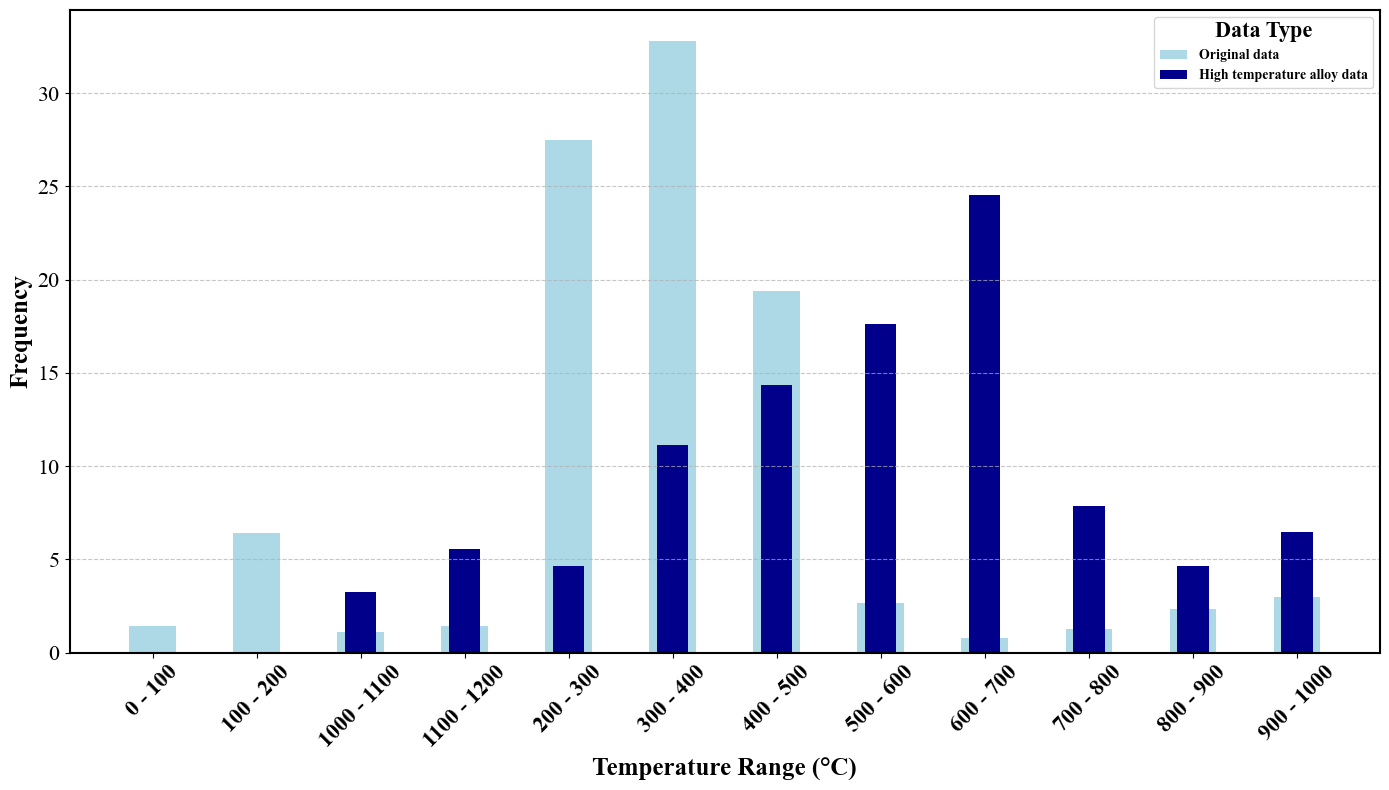

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate your data as a list of lists
data = [
    ['Additional data', '0 - 100', 0],
    ['Additional data', '100 - 200', 0],
    ['Additional data', '200 - 300', 4.62963],
    ['Additional data', '300 - 400', 11.11111],
    ['Additional data', '400 - 500', 14.35185],
    ['Additional data', '500 - 600', 17.59259],
    ['Additional data', '600 - 700', 24.53704],
    ['Additional data', '700 - 800', 7.87037],
    ['Additional data', '800 - 900', 4.62963],
    ['Additional data', '900 - 1000', 6.48148],
    ['Additional data', '1000 - 1100', 3.24074],
    ['Additional data', '1100 - 1200', 5.55556],
    ['Original data', '0 - 100', 1.40625],
    ['Original data', '100 - 200', 6.40625],
    ['Original data', '200 - 300', 27.5],
    ['Original data', '300 - 400', 32.8125],
    ['Original data', '400 - 500', 19.375],
    ['Original data', '500 - 600', 2.65625],
    ['Original data', '600 - 700', 0.78125],
    ['Original data', '700 - 800', 1.25],
    ['Original data', '800 - 900', 2.34375],
    ['Original data', '900 - 1000', 2.96875],
    ['Original data', '1000 - 1100', 1.09375],
    ['Original data', '1100 - 1200', 1.40625]
]

# Create DataFrame
df = pd.DataFrame(data, columns=['Data Type', 'Temperature Range', 'Frequency'])

# Pivot the data to have temperature ranges as index and data types as columns
df_pivot = df.pivot(index='Temperature Range', columns='Data Type', values='Frequency').fillna(0)

# Plot the data
fig, ax = plt.subplots(figsize=(14, 8))

# Set bar width
bar_width_outer = 0.45
bar_width_inner = 0.3

# Create bar positions
positions = range(len(df_pivot))

# Plot "Original data" with wider bars
bars1 = ax.bar(positions, df_pivot['Original data'], width=bar_width_outer, color='lightblue', label='Original data')

# Plot "Additional data" inside "Original data" bars with narrower width
bars2 = ax.bar(positions, df_pivot['Additional data'], width=bar_width_inner, color='darkblue', label='High temperature alloy data')

# Set the labels and title
ax.set_xlabel('Temperature Range (°C)', fontsize=18, fontweight='bold', fontname='Times New Roman')
ax.set_ylabel('Frequency', fontsize=18, fontweight='bold', fontname='Times New Roman')

# Set x-ticks
ax.set_xticks(positions)
ax.set_xticklabels(df_pivot.index, fontsize=16, fontname='Times New Roman', fontweight='bold', rotation=45)

# Customize the y-tick labels
ax.yaxis.set_tick_params(labelsize=16)
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontname('Times New Roman')

# Customize the legend
legend = ax.legend(title='Data Type', fontsize=16, prop={'family': 'Times New Roman', 'weight': 'bold'}, title_fontproperties={'family': 'Times New Roman', 'weight': 'bold', 'size': 16})

# Customize the grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Customize the plot spines
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# Adjust layout to ensure everything fits
plt.tight_layout()

# Save the plot
plt.savefig('frequency_distribution_by_temperature_range_nested_reverse.pdf', format='pdf')
plt.savefig('frequency_distribution_by_temperature_range_nested_reverse.png', format='png')

# Show the plot
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_6732\2725602445.py:65: MatplotlibDeprecationWarning: The label function was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use Tick.label1 instead.
  tick.label.set_fontname('Times New Roman')


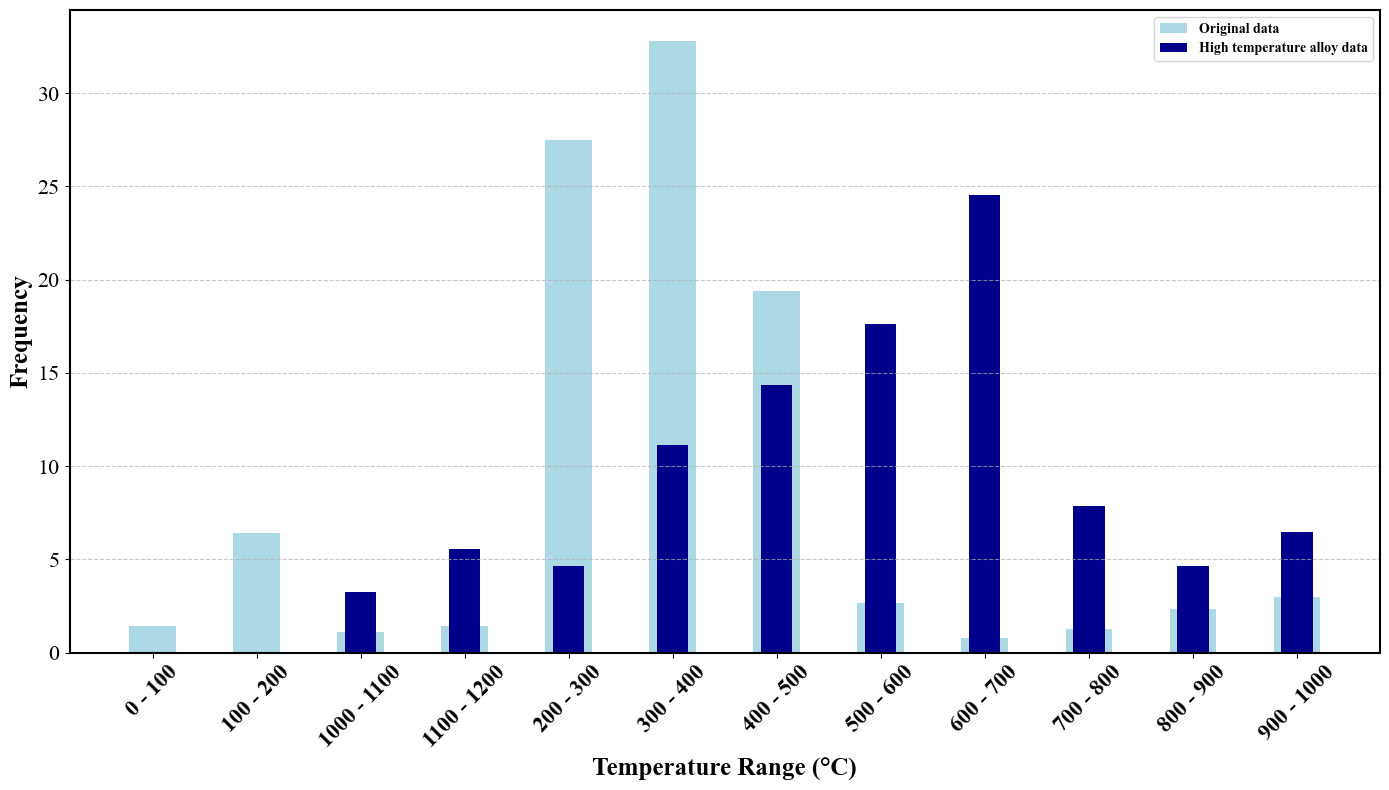

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate your data as a list of lists
data = [
    ['Additional data', '0 - 100', 0],
    ['Additional data', '100 - 200', 0],
    ['Additional data', '200 - 300', 4.62963],
    ['Additional data', '300 - 400', 11.11111],
    ['Additional data', '400 - 500', 14.35185],
    ['Additional data', '500 - 600', 17.59259],
    ['Additional data', '600 - 700', 24.53704],
    ['Additional data', '700 - 800', 7.87037],
    ['Additional data', '800 - 900', 4.62963],
    ['Additional data', '900 - 1000', 6.48148],
    ['Additional data', '1000 - 1100', 3.24074],
    ['Additional data', '1100 - 1200', 5.55556],
    ['Original data', '0 - 100', 1.40625],
    ['Original data', '100 - 200', 6.40625],
    ['Original data', '200 - 300', 27.5],
    ['Original data', '300 - 400', 32.8125],
    ['Original data', '400 - 500', 19.375],
    ['Original data', '500 - 600', 2.65625],
    ['Original data', '600 - 700', 0.78125],
    ['Original data', '700 - 800', 1.25],
    ['Original data', '800 - 900', 2.34375],
    ['Original data', '900 - 1000', 2.96875],
    ['Original data', '1000 - 1100', 1.09375],
    ['Original data', '1100 - 1200', 1.40625]
]

# Create DataFrame
df = pd.DataFrame(data, columns=['Data Type', 'Temperature Range', 'Frequency'])

# Pivot the data to have temperature ranges as index and data types as columns
df_pivot = df.pivot(index='Temperature Range', columns='Data Type', values='Frequency').fillna(0)

# Plot the data
fig, ax = plt.subplots(figsize=(14, 8))

# Set bar width
bar_width_outer = 0.45
bar_width_inner = 0.3

# Create bar positions
positions = range(len(df_pivot))

# Plot "Original data" with wider bars
bars1 = ax.bar(positions, df_pivot['Original data'], width=bar_width_outer, color='lightblue', label='Original data')

# Plot "Additional data" inside "Original data" bars with narrower width
bars2 = ax.bar(positions, df_pivot['Additional data'], width=bar_width_inner, color='darkblue', label='High temperature alloy data')

# Set the labels and title
ax.set_xlabel('Temperature Range (°C)', fontsize=18, fontweight='bold', fontname='Times New Roman')
ax.set_ylabel('Frequency', fontsize=18, fontweight='bold', fontname='Times New Roman')

# Set x-ticks
ax.set_xticks(positions)
ax.set_xticklabels(df_pivot.index, fontsize=16, fontname='Times New Roman', fontweight='bold', rotation=45)

# Customize the y-tick labels
ax.yaxis.set_tick_params(labelsize=16)
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontname('Times New Roman')

# Customize the legend
legend = ax.legend(fontsize=20, prop={'family': 'Times New Roman', 'weight': 'bold'}, title_fontproperties={'family': 'Times New Roman', 'weight': 'bold', 'size': 16})
legend.set_title(None)  # 移除图例标题

# Customize the grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Customize the plot spines
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# Adjust layout to ensure everything fits
plt.tight_layout()

# Save the plot
plt.savefig('frequency_distribution_by_temperature_range_nested_reverse.pdf', format='pdf')
plt.savefig('frequency_distribution_by_temperature_range_nested_reverse.png', format='png')

# Show the plot
plt.show()

ValueError: keyword labelweight is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_capstyle', 'grid_s

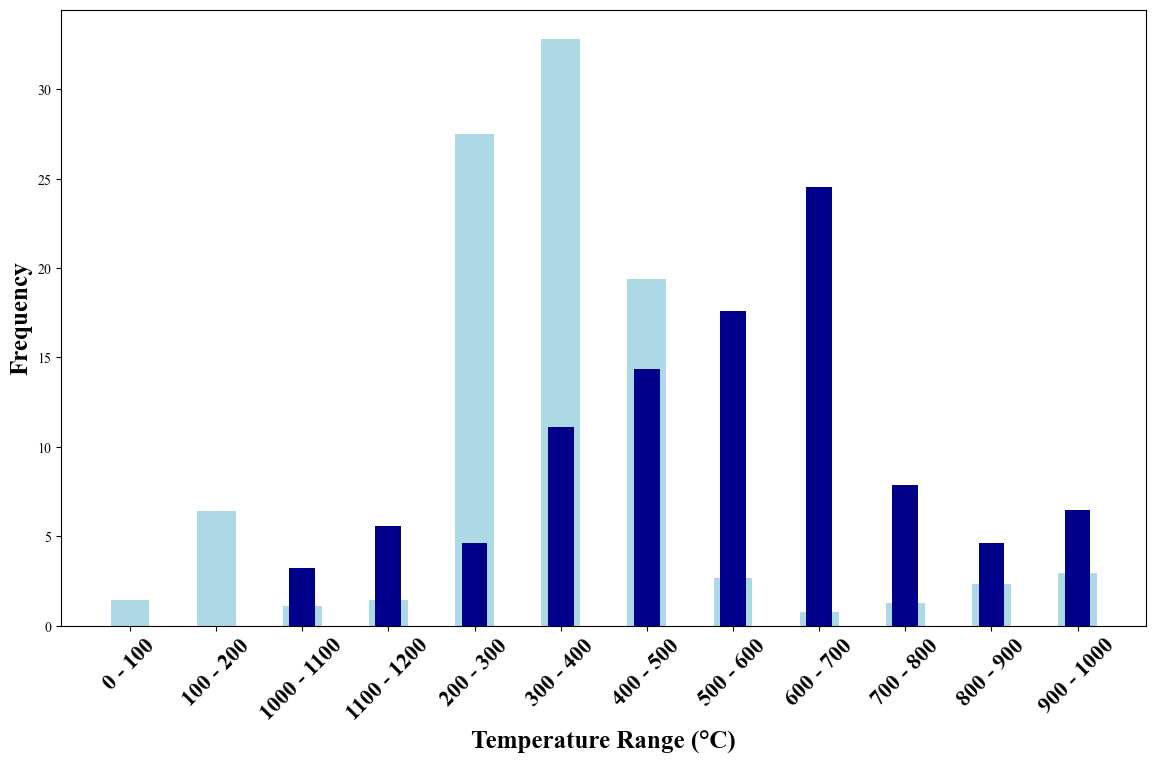

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate your data as a list of lists
data = [
    ['Additional data', '0 - 100', 0],
    ['Additional data', '100 - 200', 0],
    ['Additional data', '200 - 300', 4.62963],
    ['Additional data', '300 - 400', 11.11111],
    ['Additional data', '400 - 500', 14.35185],
    ['Additional data', '500 - 600', 17.59259],
    ['Additional data', '600 - 700', 24.53704],
    ['Additional data', '700 - 800', 7.87037],
    ['Additional data', '800 - 900', 4.62963],
    ['Additional data', '900 - 1000', 6.48148],
    ['Additional data', '1000 - 1100', 3.24074],
    ['Additional data', '1100 - 1200', 5.55556],
    ['Original data', '0 - 100', 1.40625],
    ['Original data', '100 - 200', 6.40625],
    ['Original data', '200 - 300', 27.5],
    ['Original data', '300 - 400', 32.8125],
    ['Original data', '400 - 500', 19.375],
    ['Original data', '500 - 600', 2.65625],
    ['Original data', '600 - 700', 0.78125],
    ['Original data', '700 - 800', 1.25],
    ['Original data', '800 - 900', 2.34375],
    ['Original data', '900 - 1000', 2.96875],
    ['Original data', '1000 - 1100', 1.09375],
    ['Original data', '1100 - 1200', 1.40625]
]

# Create DataFrame
df = pd.DataFrame(data, columns=['Data Type', 'Temperature Range', 'Frequency'])

# Pivot the data to have temperature ranges as index and data types as columns
df_pivot = df.pivot(index='Temperature Range', columns='Data Type', values='Frequency').fillna(0)

# Plot the data
fig, ax = plt.subplots(figsize=(14, 8))

# Set bar width
bar_width_outer = 0.45
bar_width_inner = 0.3

# Create bar positions
positions = range(len(df_pivot))

# Plot "Original data" with wider bars
bars1 = ax.bar(positions, df_pivot['Original data'], width=bar_width_outer, color='lightblue', label='Original data')

# Plot "Additional data" inside "Original data" bars with narrower width
bars2 = ax.bar(positions, df_pivot['Additional data'], width=bar_width_inner, color='darkblue', label='High temperature alloy data')

# Set the labels and title
ax.set_xlabel('Temperature Range (°C)', fontsize=18, fontweight='bold', fontname='Times New Roman')
ax.set_ylabel('Frequency', fontsize=18, fontweight='bold', fontname='Times New Roman')

# Set x-ticks
ax.set_xticks(positions)
ax.set_xticklabels(df_pivot.index, fontsize=16, fontname='Times New Roman', fontweight='bold', rotation=45)

# Customize the y-tick labels
ax.tick_params(axis='y', labelsize=16, labelweight='bold')
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontname('Times New Roman')

# Customize the legend
legend = ax.legend(fontsize=20, prop={'family': 'Times New Roman', 'weight': 'bold'})
legend.set_title(None)  # 移除图例标题

# Customize the grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Customize the plot spines
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# Adjust layout to ensure everything fits
plt.tight_layout()

# Save the plot
plt.savefig('frequency_distribution_by_temperature_range_nested_reverse.pdf', format='pdf')
plt.savefig('frequency_distribution_by_temperature_range_nested_reverse.png', format='png')

# Show the plot
plt.show()

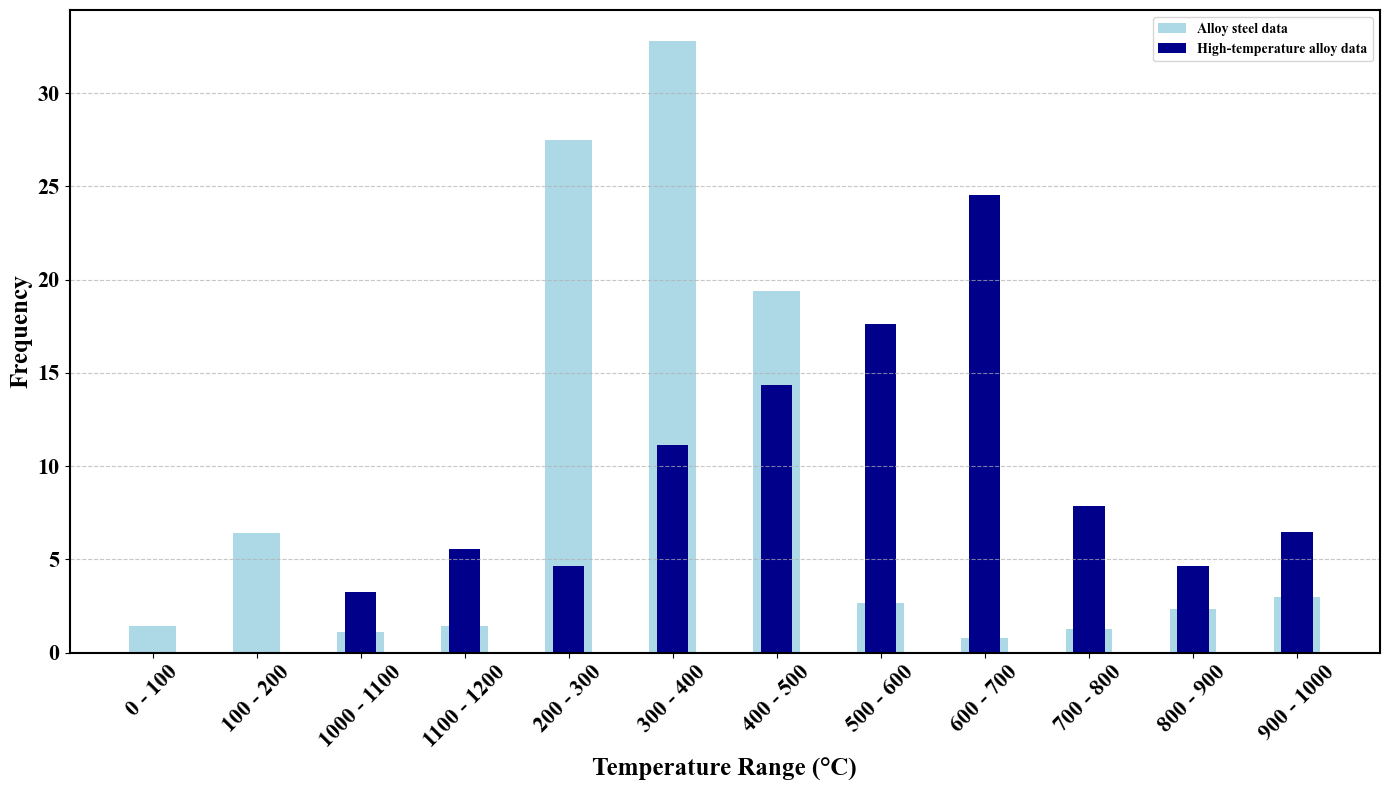

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate your data as a list of lists
data = [
    ['Additional data', '0 - 100', 0],
    ['Additional data', '100 - 200', 0],
    ['Additional data', '200 - 300', 4.62963],
    ['Additional data', '300 - 400', 11.11111],
    ['Additional data', '400 - 500', 14.35185],
    ['Additional data', '500 - 600', 17.59259],
    ['Additional data', '600 - 700', 24.53704],
    ['Additional data', '700 - 800', 7.87037],
    ['Additional data', '800 - 900', 4.62963],
    ['Additional data', '900 - 1000', 6.48148],
    ['Additional data', '1000 - 1100', 3.24074],
    ['Additional data', '1100 - 1200', 5.55556],
    ['Original data', '0 - 100', 1.40625],
    ['Original data', '100 - 200', 6.40625],
    ['Original data', '200 - 300', 27.5],
    ['Original data', '300 - 400', 32.8125],
    ['Original data', '400 - 500', 19.375],
    ['Original data', '500 - 600', 2.65625],
    ['Original data', '600 - 700', 0.78125],
    ['Original data', '700 - 800', 1.25],
    ['Original data', '800 - 900', 2.34375],
    ['Original data', '900 - 1000', 2.96875],
    ['Original data', '1000 - 1100', 1.09375],
    ['Original data', '1100 - 1200', 1.40625]
]

# Create DataFrame
df = pd.DataFrame(data, columns=['Data Type', 'Temperature Range', 'Frequency'])

# Pivot the data to have temperature ranges as index and data types as columns
df_pivot = df.pivot(index='Temperature Range', columns='Data Type', values='Frequency').fillna(0)

# Plot the data
fig, ax = plt.subplots(figsize=(14, 8))

# Set bar width
bar_width_outer = 0.45
bar_width_inner = 0.3

# Create bar positions
positions = range(len(df_pivot))

# Plot "Original data" with wider bars
bars1 = ax.bar(positions, df_pivot['Original data'], width=bar_width_outer, color='lightblue', label='Alloy steel data')

# Plot "Additional data" inside "Original data" bars with narrower width
bars2 = ax.bar(positions, df_pivot['Additional data'], width=bar_width_inner, color='darkblue', label='High-temperature alloy data')

# Set the labels and title
ax.set_xlabel('Temperature Range (°C)', fontsize=18, fontweight='bold', fontname='Times New Roman')
ax.set_ylabel('Frequency', fontsize=18, fontweight='bold', fontname='Times New Roman')

# Set x-ticks
ax.set_xticks(positions)
ax.set_xticklabels(df_pivot.index, fontsize=16, fontname='Times New Roman', fontweight='bold', rotation=45)

# Customize the y-tick labels
ax.tick_params(axis='y', labelsize=16)
for tick in ax.get_yticklabels():
    tick.set_fontname('Times New Roman')
    tick.set_fontweight('bold')

# Customize the legend
legend = ax.legend(fontsize=24, prop={'family': 'Times New Roman', 'weight': 'bold'})
legend.set_title(None)  # 移除图例标题

# Customize the grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Customize the plot spines
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# Adjust layout to ensure everything fits
plt.tight_layout()

# Save the plot
plt.savefig('frequency_distribution_by_temperature_range_nested_reverse.pdf', format='pdf')
plt.savefig('frequency_distribution_by_temperature_range_nested_reverse.png', format='png')

# Show the plot
plt.show()

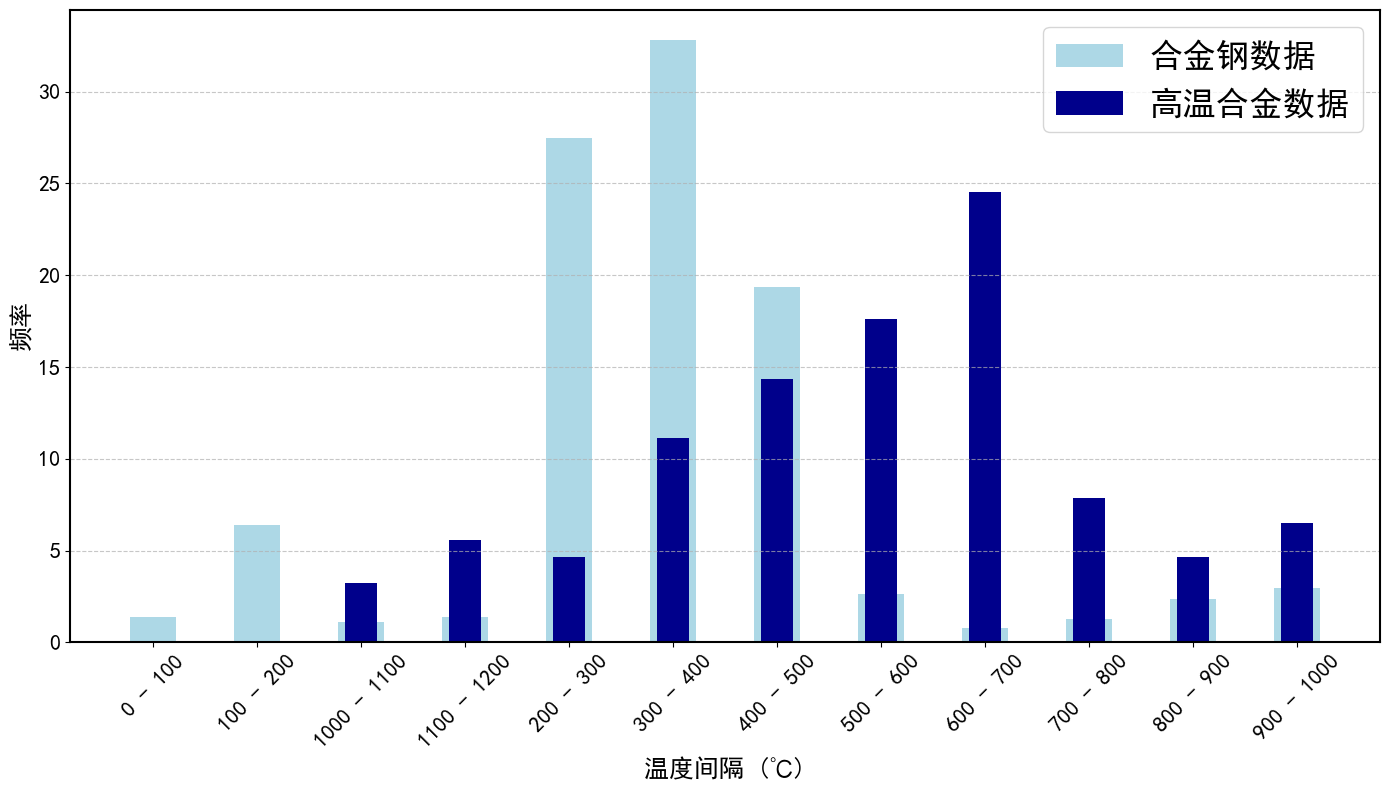

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 设置matplotlib的中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 或其他支持中文的字体，如 'SimSun'
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 重现你的数据为列表的列表
data = [
    ['Additional data', '0 - 100', 0],
    ['Additional data', '100 - 200', 0],
    ['Additional data', '200 - 300', 4.62963],
    ['Additional data', '300 - 400', 11.11111],
    ['Additional data', '400 - 500', 14.35185],
    ['Additional data', '500 - 600', 17.59259],
    ['Additional data', '600 - 700', 24.53704],
    ['Additional data', '700 - 800', 7.87037],
    ['Additional data', '800 - 900', 4.62963],
    ['Additional data', '900 - 1000', 6.48148],
    ['Additional data', '1000 - 1100', 3.24074],
    ['Additional data', '1100 - 1200', 5.55556],
    ['Original data', '0 - 100', 1.40625],
    ['Original data', '100 - 200', 6.40625],
    ['Original data', '200 - 300', 27.5],
    ['Original data', '300 - 400', 32.8125],
    ['Original data', '400 - 500', 19.375],
    ['Original data', '500 - 600', 2.65625],
    ['Original data', '600 - 700', 0.78125],
    ['Original data', '700 - 800', 1.25],
    ['Original data', '800 - 900', 2.34375],
    ['Original data', '900 - 1000', 2.96875],
    ['Original data', '1000 - 1100', 1.09375],
    ['Original data', '1100 - 1200', 1.40625]
]

# 创建DataFrame
df = pd.DataFrame(data, columns=['Data Type', 'Temperature Range', 'Frequency'])

# 数据透视表，将温度范围作为索引，数据类型作为列
df_pivot = df.pivot(index='Temperature Range', columns='Data Type', values='Frequency').fillna(0)

# 绘制数据
fig, ax = plt.subplots(figsize=(14, 8))

# 设置柱状图宽度
bar_width_outer = 0.45
bar_width_inner = 0.3

# 创建柱状图位置
positions = range(len(df_pivot))

# 绘制“合金钢数据”柱状图，使用较宽的柱子
bars1 = ax.bar(positions, df_pivot['Original data'], width=bar_width_outer, color='lightblue', label='合金钢数据')

# 在“合金钢数据”柱状图内部绘制“高温合金数据”柱状图，使用较窄的柱子
bars2 = ax.bar(positions, df_pivot['Additional data'], width=bar_width_inner, color='darkblue', label='高温合金数据')

# 设置标签和标题
ax.set_xlabel('温度间隔 (℃)', fontsize=18, fontweight='bold')
ax.set_ylabel('频率', fontsize=18, fontweight='bold')

# 设置x轴刻度
ax.set_xticks(positions)
ax.set_xticklabels(df_pivot.index, fontsize=16, fontweight='bold', rotation=45)

# 自定义y轴刻度标签
ax.tick_params(axis='y', labelsize=16)

# 自定义图例
legend = ax.legend(fontsize=24)
legend.set_title(None)  # 移除图例标题

# 自定义网格
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 自定义图表边框
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

# 调整布局以确保所有内容都适合
plt.tight_layout()

# 保存图像
plt.savefig('合金钢与高温合金钢数据对比.pdf', format='pdf')
plt.savefig('合金钢与高温合金钢数据对比.png', format='png')

# 显示图像
plt.show()